<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Trustworthy_Explainable_Artificial_Intelligence_for_Early_Heart_Disease_Risk_Prediction_A_Comparative_Study_of_Machine_Learning_Models_with_Fairness_and_Uncertainty_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip install -q xgboost lightgbm catboost shap lime statsmodels openpyxl

In [71]:
# ============================================================
# Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import gc
import time
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef,
    cohen_kappa_score
)

import xgboost as xgb
import lightgbm as lgb

from catboost import CatBoostClassifier

# Explainable AI
import shap
import lime
import lime.lime_tabular

# Statistical comparison
from statsmodels.stats.contingency_tables import mcnemar

# Calibration
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV

# Plot Settings
sns.set_style("whitegrid")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("All libraries imported successfully.")

All libraries imported successfully.


In [72]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv(
    "/content/drive/MyDrive/Dataset/Cardiovascular_Disease_Dataset.csv"
)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [74]:
# ============================================================
# Dataset Overview
# ============================================================

print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("COLUMN NAMES")
print("="*60)

print(df.columns.tolist())

print("\n")

print("="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)

print("\n")

print("="*60)
print("FIRST FIVE ROWS")
print("="*60)

display(df.head())

DATASET SHAPE
(1000, 14)


COLUMN NAMES
['patientid', 'age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels', 'target']


DATA TYPES
patientid              int64
age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object


FIRST FIVE ROWS


,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [75]:
# ============================================================
# Dataset Information
# ============================================================

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [76]:
# ============================================================
# Missing Values
# ============================================================

missing = pd.DataFrame({

    "Missing Values":df.isnull().sum(),

    "Percentage":(
        df.isnull().sum()/len(df)*100
    ).round(2)

})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing)

,Missing Values,Percentage
patientid,0,0.0
age,0,0.0
gender,0,0.0
chestpain,0,0.0
restingBP,0,0.0
serumcholestrol,0,0.0
fastingbloodsugar,0,0.0
restingrelectro,0,0.0
maxheartrate,0,0.0
exerciseangia,0,0.0


In [77]:
# ============================================================
# Duplicate Records
# ============================================================

duplicates = df.duplicated().sum()

print("Number of Duplicate Rows :", duplicates)

if duplicates > 0:

    print("Removing duplicate rows...")

    df = df.drop_duplicates()

    print("New Shape :", df.shape)

else:

    print("No duplicate records found.")

Number of Duplicate Rows : 0
No duplicate records found.


In [78]:
# ============================================================
# Descriptive Statistics
# ============================================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
patientid,1000.0,5.048704e+06,2.895905e+06,103368.0,2536439.50,4952508.5,7681877.00,9990855.0
age,1000.0,4.924200e+01,1.786473e+01,20.0,34.00,49.0,64.25,80.0
gender,1000.0,7.650000e-01,4.242110e-01,0.0,1.00,1.0,1.00,1.0
chestpain,1000.0,9.800000e-01,9.531571e-01,0.0,0.00,1.0,2.00,3.0
restingBP,1000.0,1.517470e+02,2.996523e+01,94.0,129.00,147.0,181.00,200.0
serumcholestrol,1000.0,3.114470e+02,1.324438e+02,0.0,235.75,318.0,404.25,602.0
fastingbloodsugar,1000.0,2.960000e-01,4.567194e-01,0.0,0.00,0.0,1.00,1.0
restingrelectro,1000.0,7.480000e-01,7.701228e-01,0.0,0.00,1.0,1.00,2.0
maxheartrate,1000.0,1.454770e+02,3.419027e+01,71.0,119.75,146.0,175.00,202.0
exerciseangia,1000.0,4.980000e-01,5.002462e-01,0.0,0.00,0.0,1.00,1.0


In [79]:
# ============================================================
# Target Distribution
# ============================================================

print(df["target"].value_counts())

print()

print(df["target"].value_counts(normalize=True)*100)

target
1    580
0    420
Name: count, dtype: int64

target
1    58.0
0    42.0
Name: proportion, dtype: float64


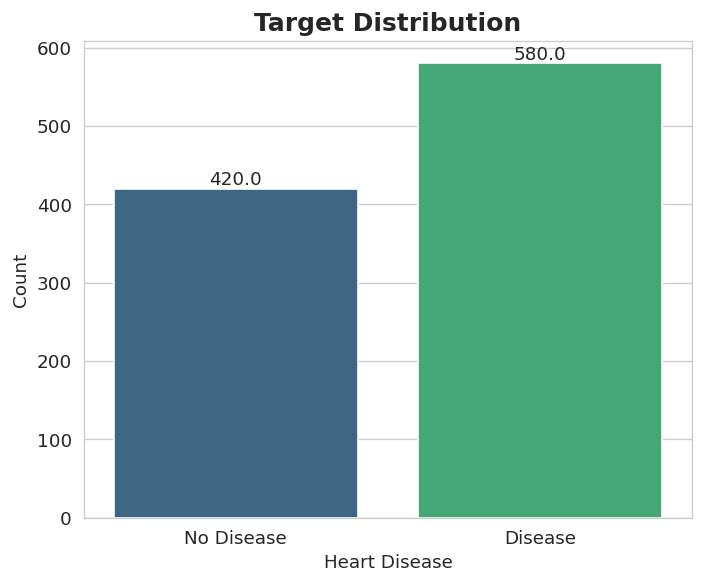

In [80]:
# ============================================================
# Target Distribution Plot
# ============================================================

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="target",
    palette="viridis"
)

plt.title(
    "Target Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Heart Disease")

plt.ylabel("Count")

ax.set_xticklabels([
    "No Disease",
    "Disease"
])

for p in ax.patches:

    ax.annotate(
        f"{p.get_height()}",
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.show()

In [81]:
# ============================================================
# Dataset Summary
# ============================================================

print("="*70)

print("DATASET SUMMARY")

print("="*70)

print(f"Number of Samples      : {df.shape[0]}")

print(f"Number of Features     : {df.shape[1]-1}")

print(f"Target Column          : target")

print(f"Missing Values         : {df.isnull().sum().sum()}")

print(f"Duplicate Rows         : {df.duplicated().sum()}")

print(f"Positive Cases         : {df['target'].sum()}")

print(f"Negative Cases         : {(df['target']==0).sum()}")

print("="*70)

DATASET SUMMARY
Number of Samples      : 1000
Number of Features     : 13
Target Column          : target
Missing Values         : 0
Duplicate Rows         : 0
Positive Cases         : 580
Negative Cases         : 420


In [82]:
# ============================================================
# Separate Numerical and Categorical Features
# ============================================================

numerical_features = [
    'age',
    'restingBP',
    'serumcholestrol',
    'maxheartrate',
    'oldpeak',
    'noofmajorvessels'
]

categorical_features = [
    'gender',
    'chestpain',
    'fastingbloodsugar',
    'restingrelectro',
    'exerciseangia',
    'slope'
]

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak', 'noofmajorvessels']

Categorical Features
['gender', 'chestpain', 'fastingbloodsugar', 'restingrelectro', 'exerciseangia', 'slope']


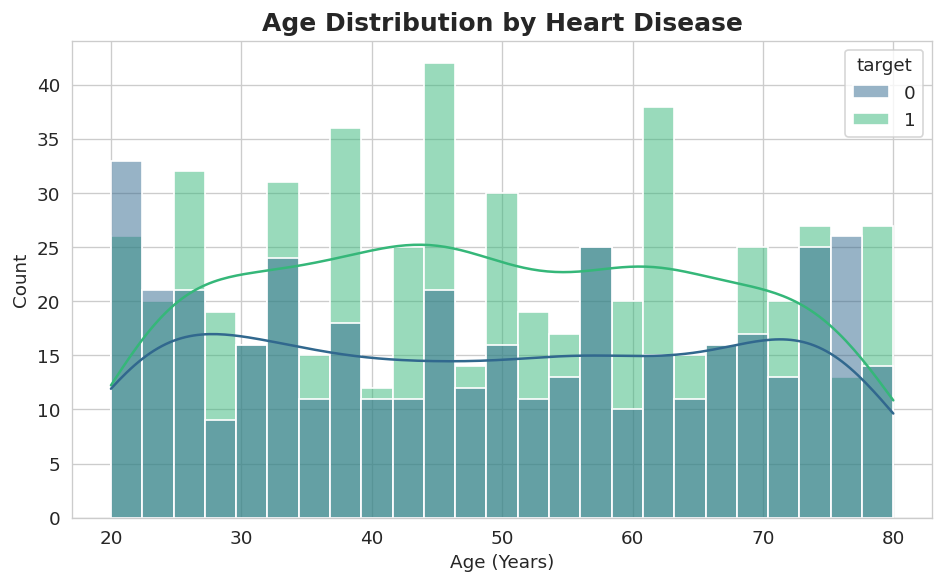

In [83]:
# ============================================================
# Age Distribution
# ============================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    hue='target',
    bins=25,
    kde=True,
    palette='viridis'
)

plt.title("Age Distribution by Heart Disease",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Age (Years)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

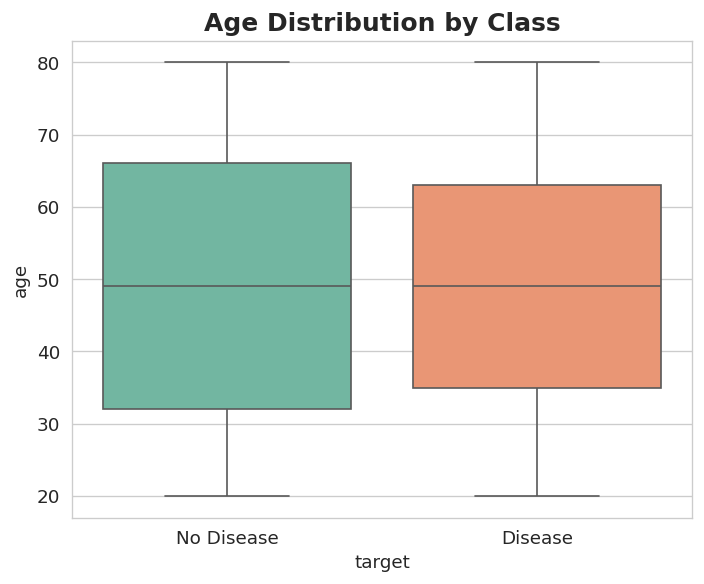

In [84]:
# ============================================================
# Age Boxplot
# ============================================================

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x='target',
    y='age',
    palette='Set2'
)

plt.xticks([0,1],["No Disease","Disease"])

plt.title("Age Distribution by Class",
          fontsize=15,
          fontweight='bold')

plt.tight_layout()

plt.show()

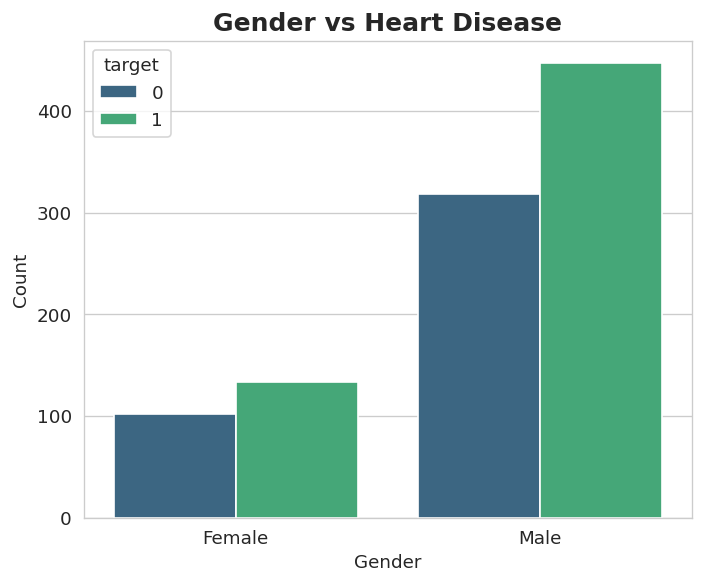

In [85]:
# ============================================================
# Gender Distribution
# ============================================================

plt.figure(figsize=(6,5))

ax=sns.countplot(
    data=df,
    x='gender',
    hue='target',
    palette='viridis'
)

plt.xticks([0,1],["Female","Male"])

plt.title("Gender vs Heart Disease",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

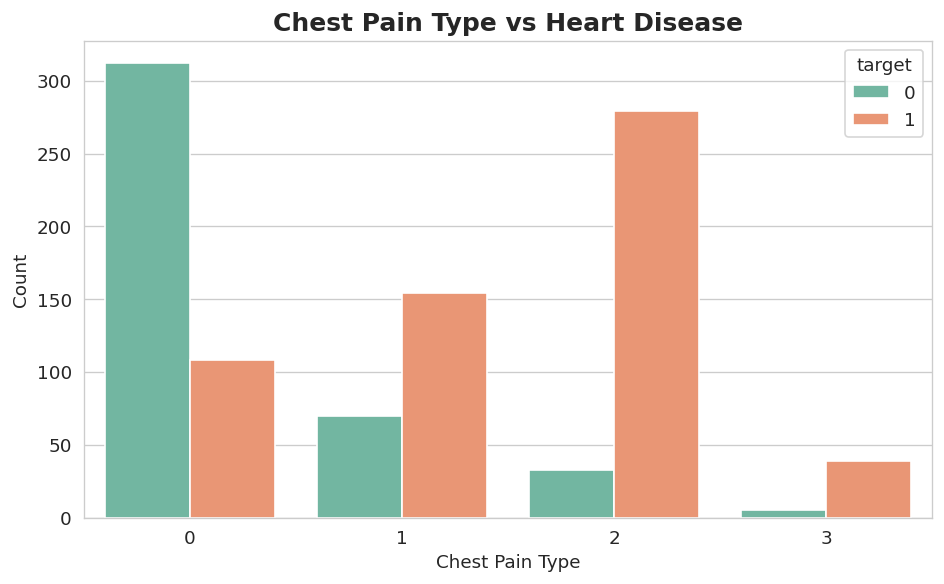

In [86]:
# ============================================================
# Chest Pain Type
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='chestpain',
    hue='target',
    palette='Set2'
)

plt.title("Chest Pain Type vs Heart Disease",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

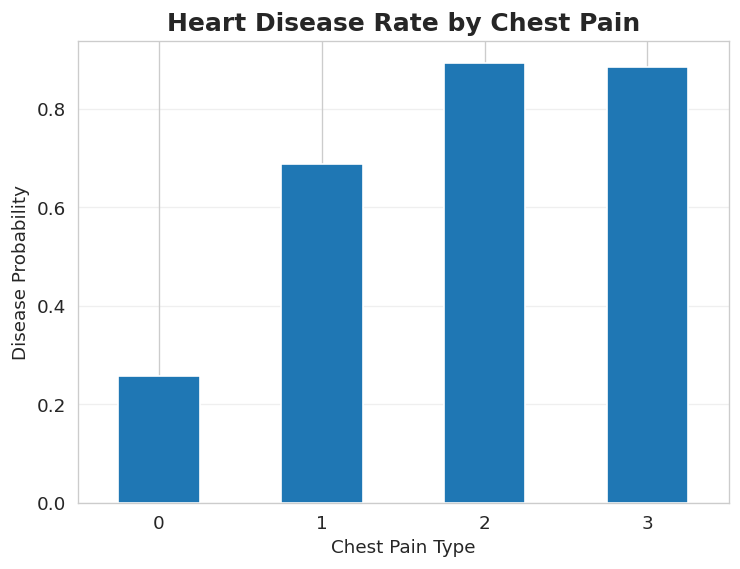

In [87]:
# ============================================================
# Heart Disease Rate by Chest Pain
# ============================================================

risk=df.groupby('chestpain')['target'].mean()

plt.figure(figsize=(7,5))

risk.plot(
    kind='bar',
    rot=0
)

plt.ylabel("Disease Probability")
plt.xlabel("Chest Pain Type")

plt.title("Heart Disease Rate by Chest Pain",
          fontsize=15,
          fontweight='bold')

plt.grid(axis='y',alpha=.3)

plt.show()

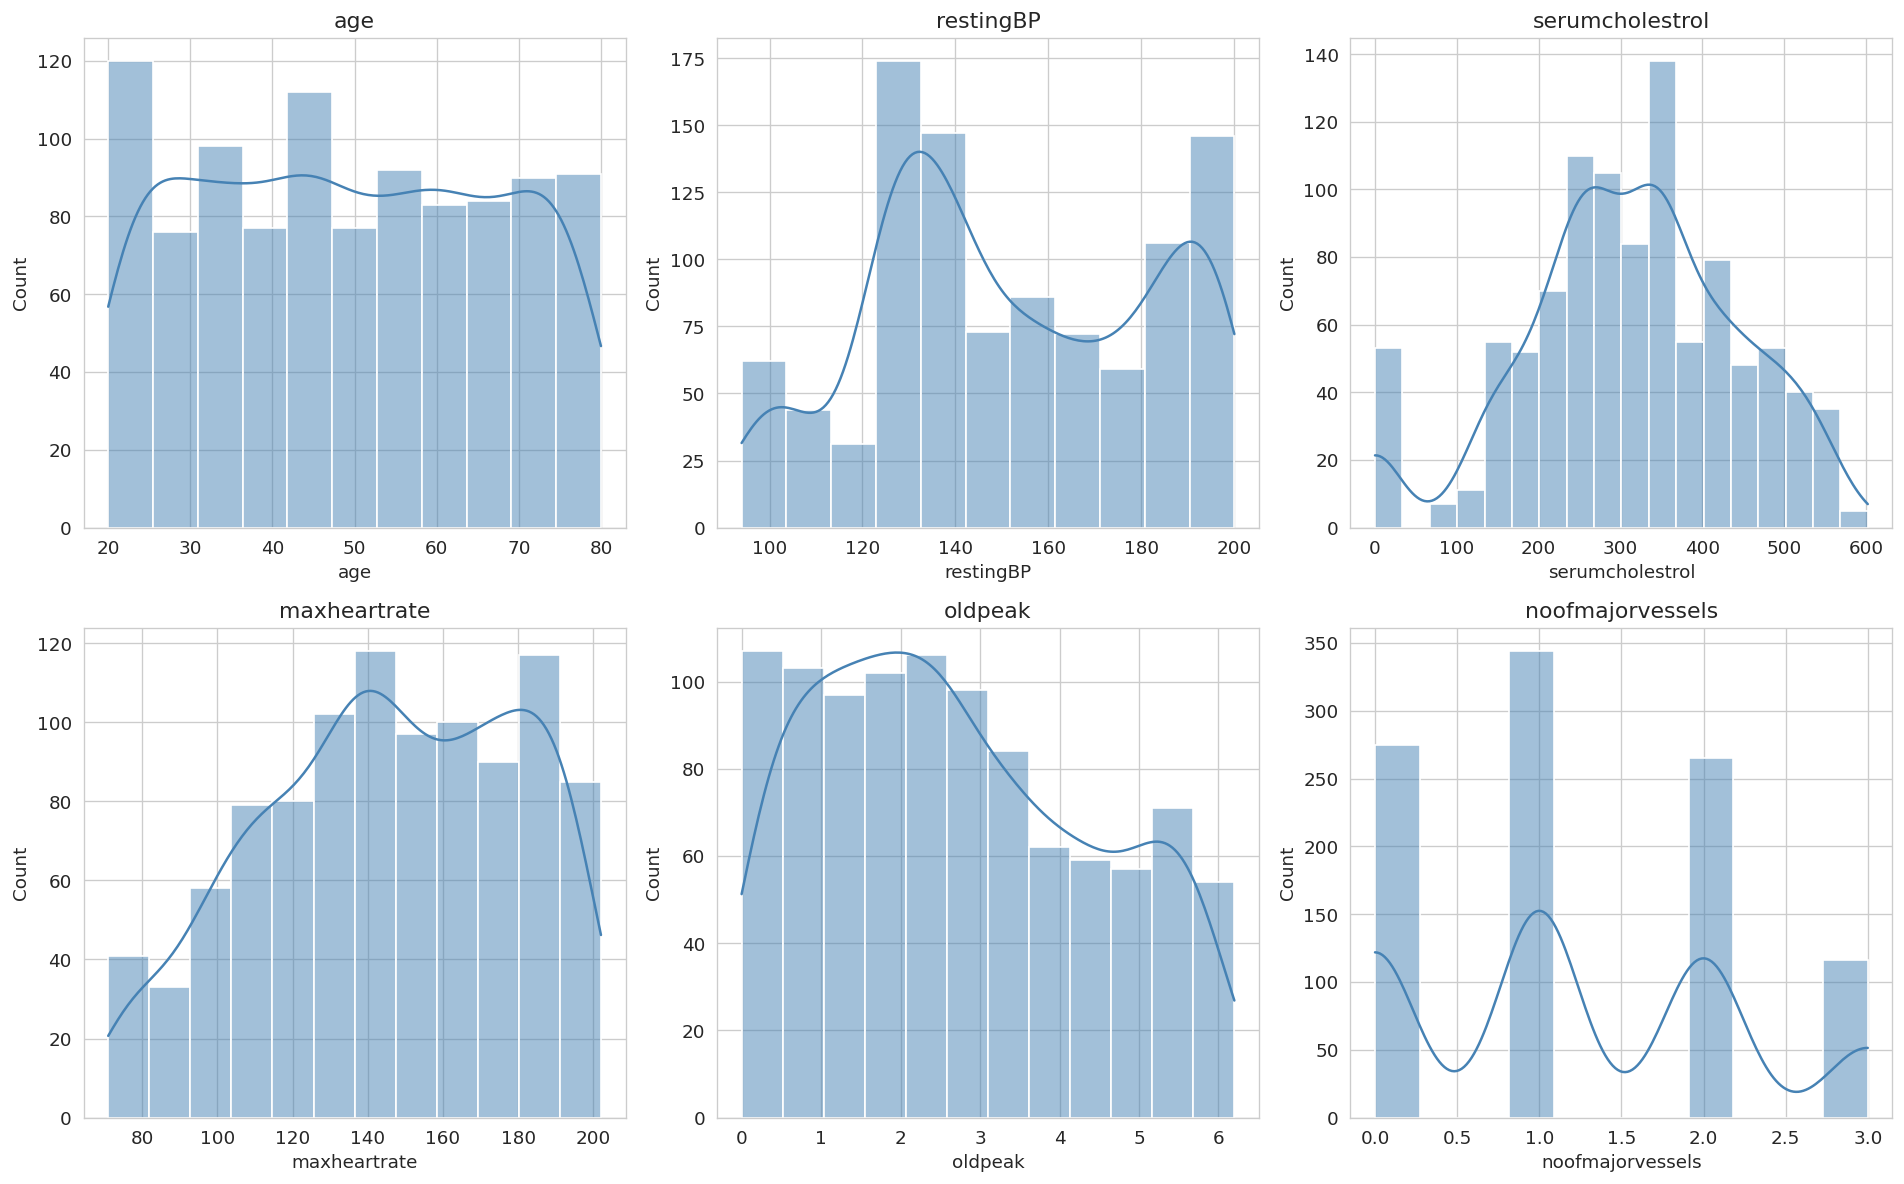

In [88]:
# ============================================================
# Histograms
# ============================================================

fig,axes=plt.subplots(2,3,figsize=(16,10))

axes=axes.flatten()

for i,col in enumerate(numerical_features):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color='steelblue',
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

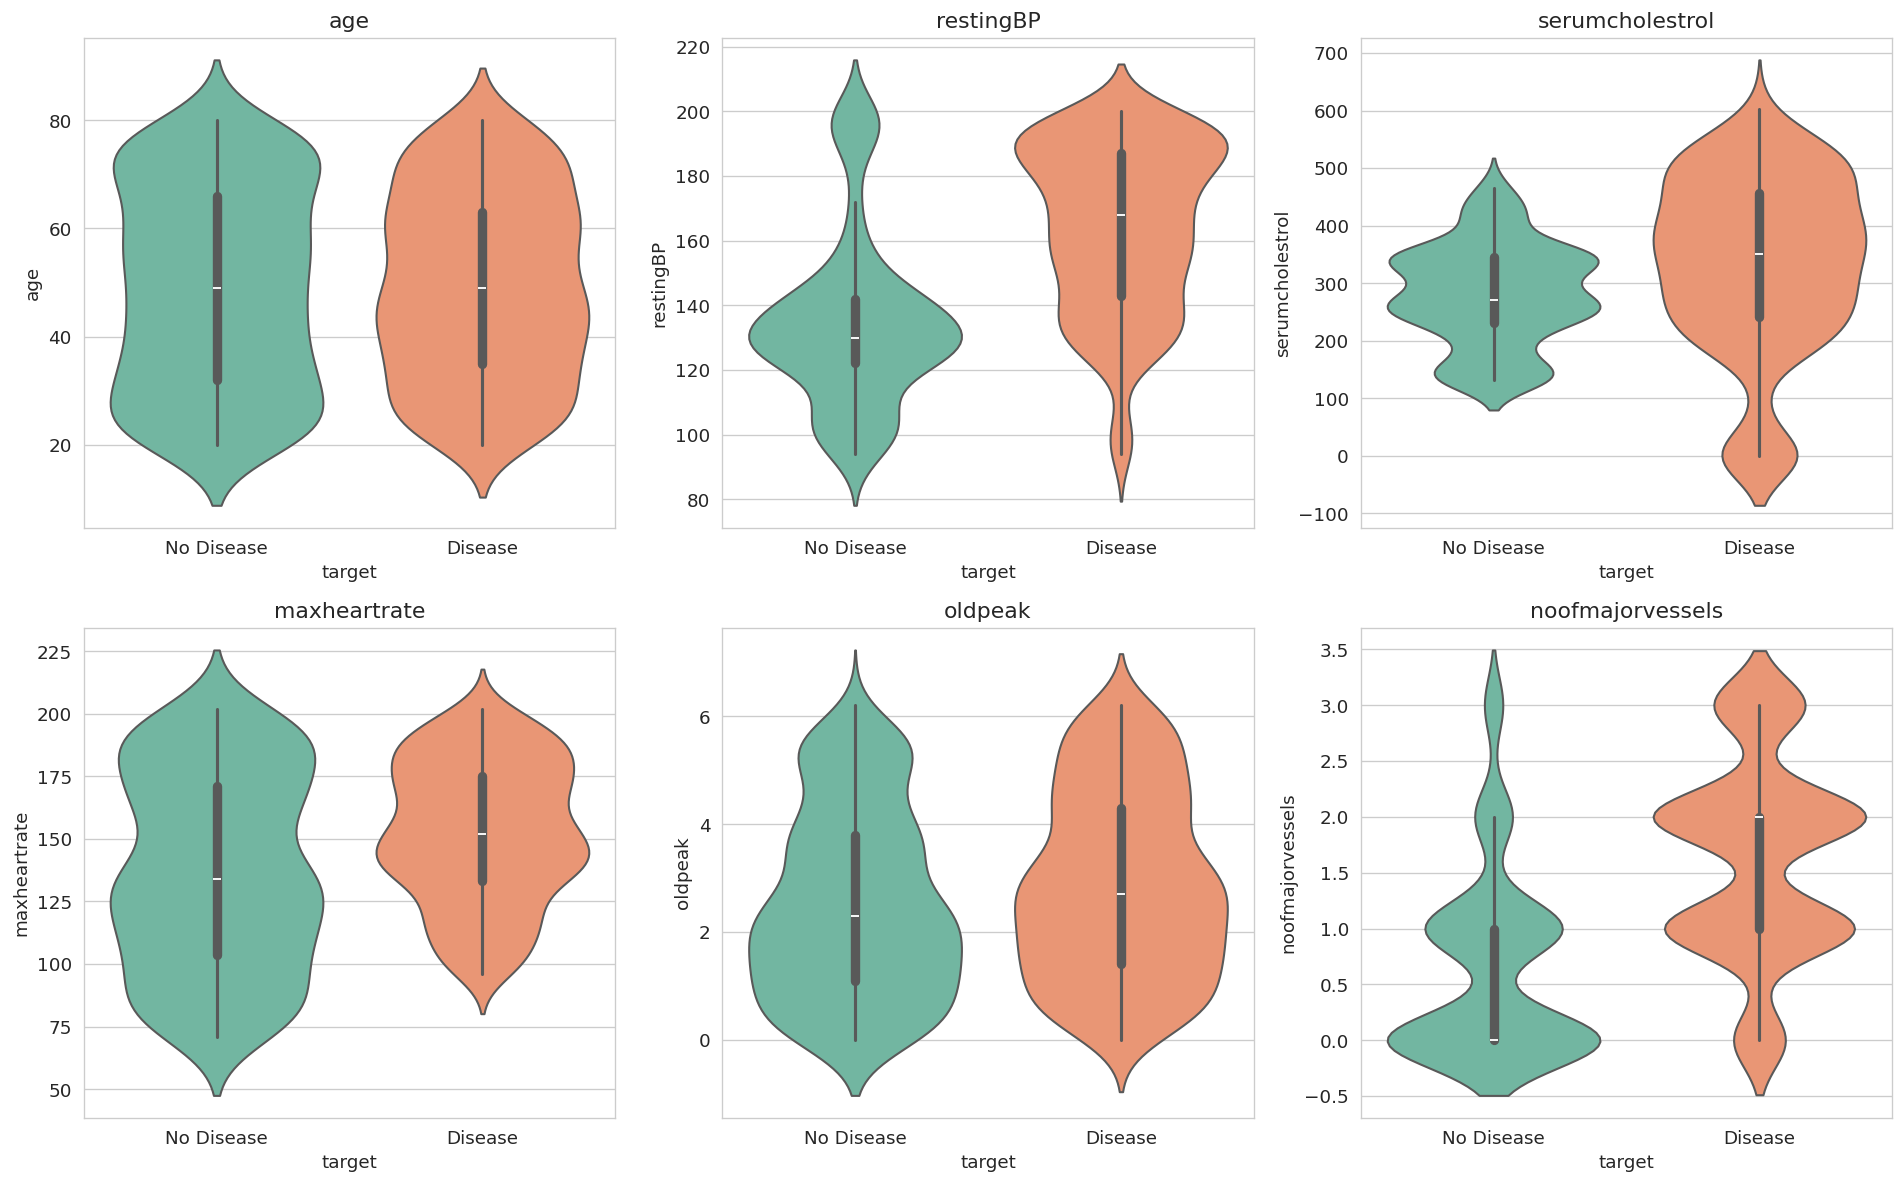

In [89]:
# ============================================================
# Violin Plots
# ============================================================

fig,axes=plt.subplots(2,3,figsize=(16,10))

axes=axes.flatten()

for i,col in enumerate(numerical_features):

    sns.violinplot(
        data=df,
        x='target',
        y=col,
        palette='Set2',
        ax=axes[i]
    )

    axes[i].set_xticklabels(["No Disease","Disease"])

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

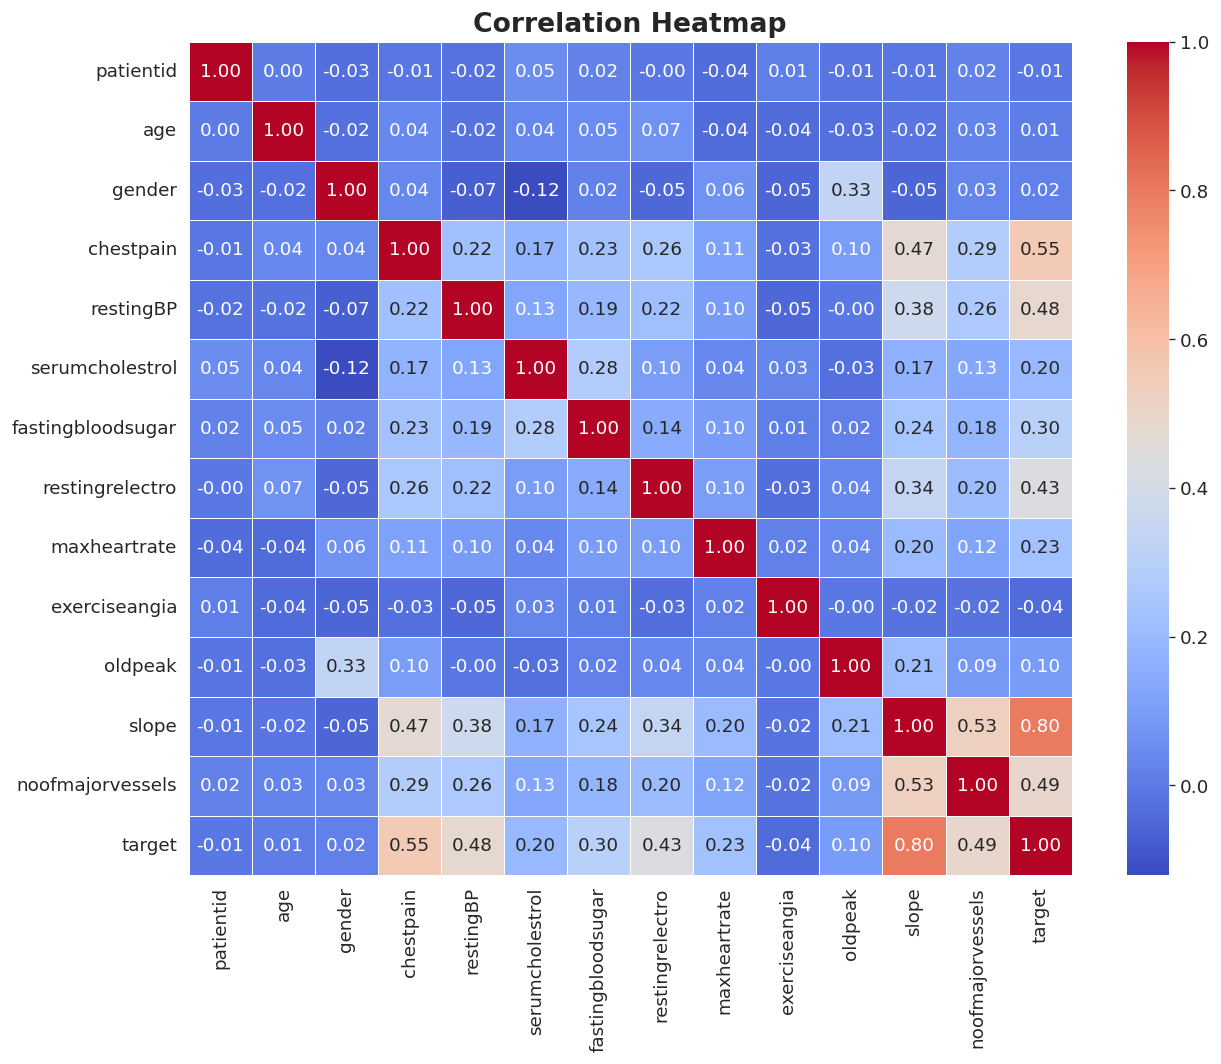

In [90]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(11,9))

corr=df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)

plt.title("Correlation Heatmap",
          fontsize=16,
          fontweight='bold')

plt.tight_layout()

plt.show()

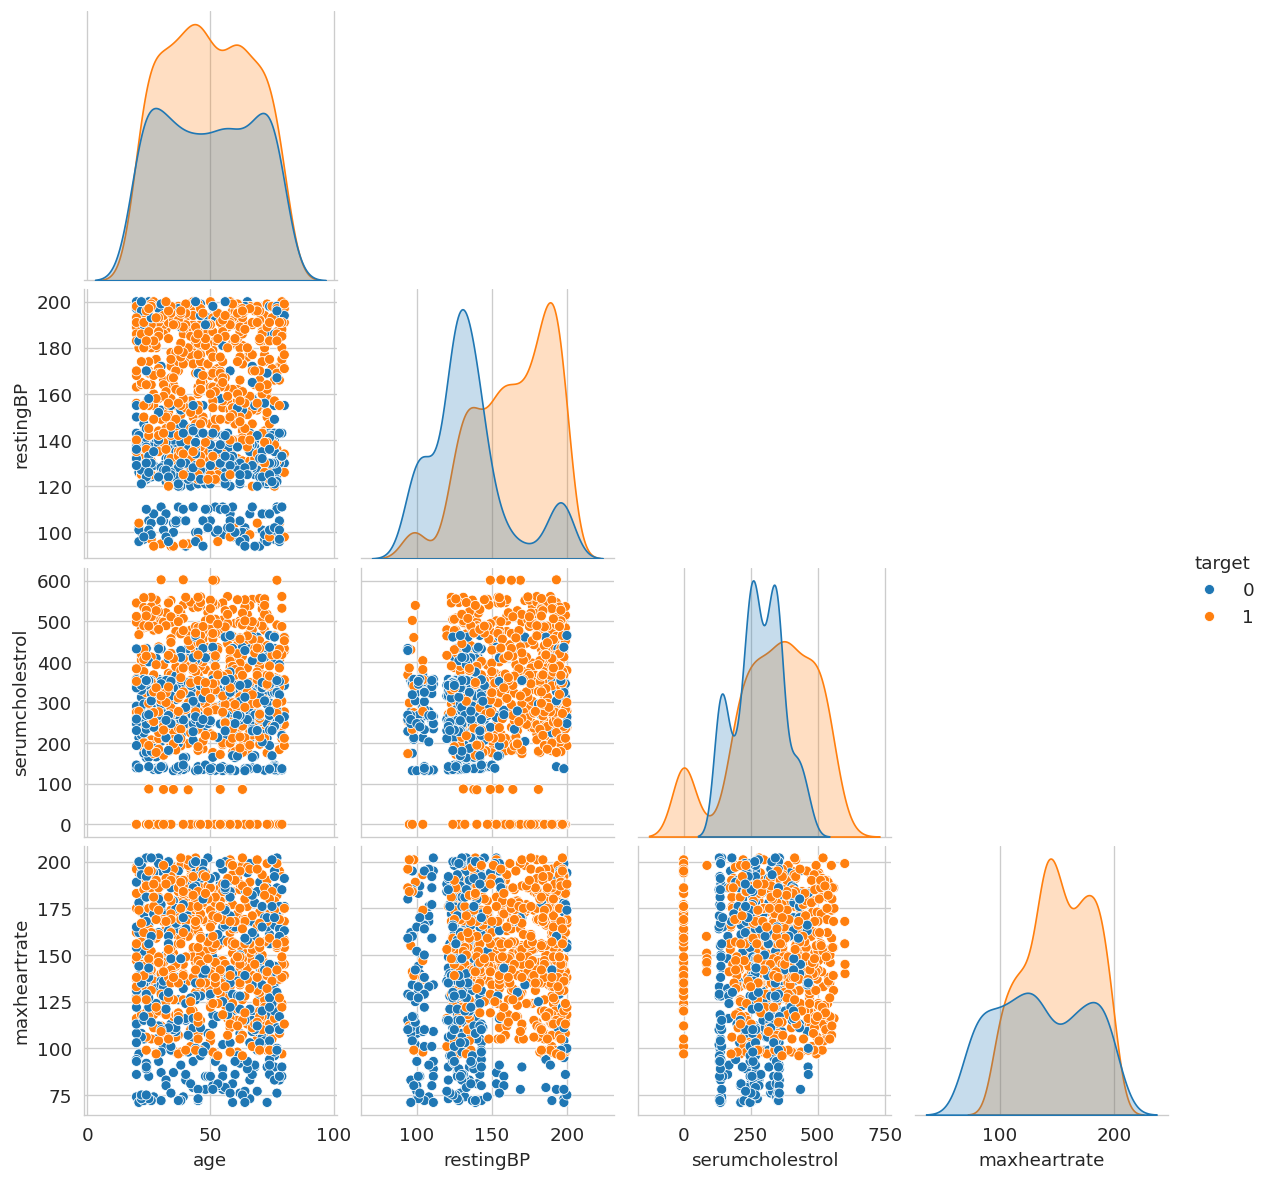

In [91]:
# ============================================================
# Pairplot
# ============================================================

pair_columns=[
    'age',
    'restingBP',
    'serumcholestrol',
    'maxheartrate',
    'target'
]

sns.pairplot(
    df[pair_columns],
    hue='target',
    diag_kind='kde',
    corner=True
)

plt.show()

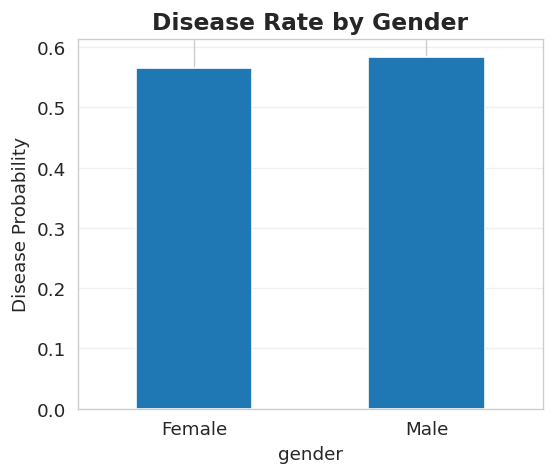

In [92]:
# ============================================================
# Disease Rate by Gender
# ============================================================

gender_rate=df.groupby('gender')['target'].mean()

plt.figure(figsize=(5,4))

gender_rate.plot(
    kind='bar'
)

plt.xticks([0,1],["Female","Male"],rotation=0)

plt.ylabel("Disease Probability")

plt.title("Disease Rate by Gender",
          fontsize=14,
          fontweight='bold')

plt.grid(axis='y',alpha=.3)

plt.show()

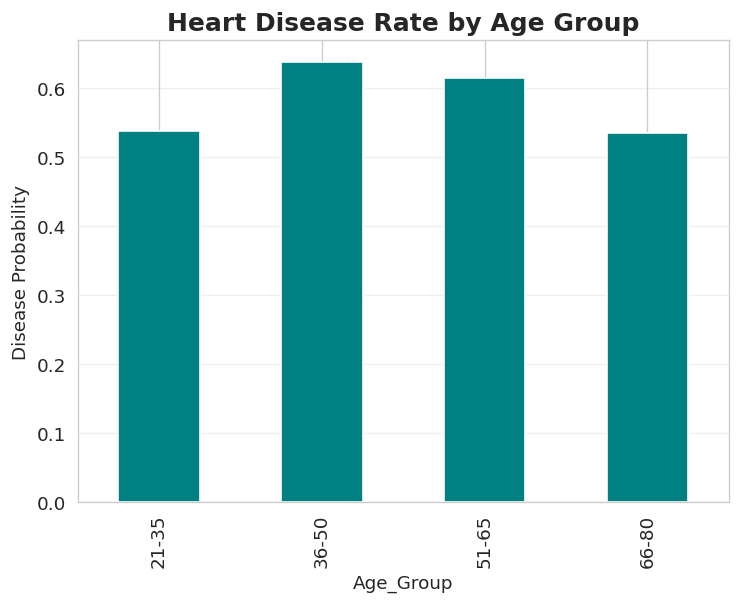

In [93]:
# ============================================================
# Age Groups
# ============================================================

df['Age_Group']=pd.cut(
    df['age'],
    bins=[20,35,50,65,80],
    labels=[
        '21-35',
        '36-50',
        '51-65',
        '66-80'
    ]
)

age_rate=df.groupby('Age_Group')['target'].mean()

plt.figure(figsize=(7,5))

age_rate.plot(
    kind='bar',
    color='teal'
)

plt.ylabel("Disease Probability")

plt.title("Heart Disease Rate by Age Group",
          fontsize=15,
          fontweight='bold')

plt.grid(axis='y',alpha=.3)

plt.show()

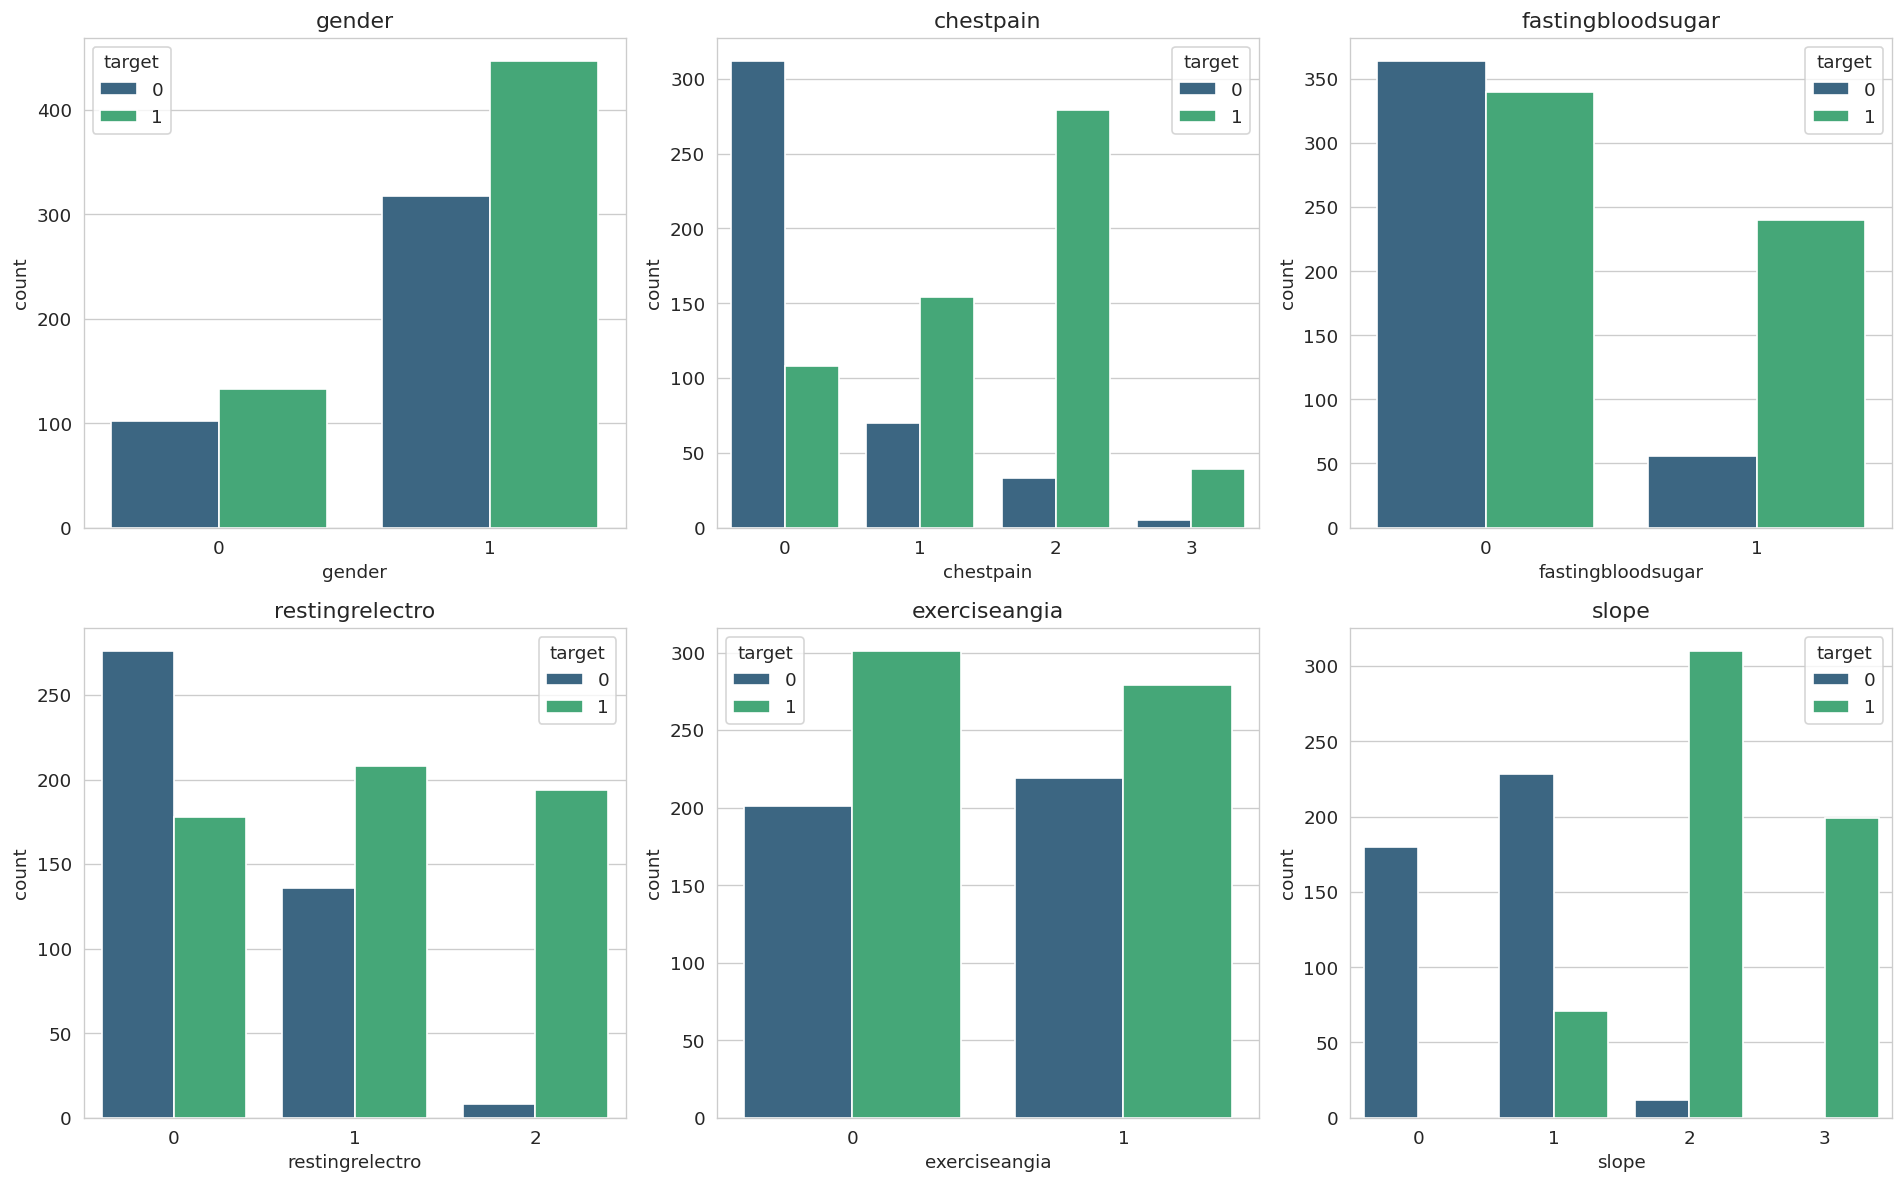

In [94]:
# ============================================================
# Countplots of Categorical Features
# ============================================================

fig,axes=plt.subplots(2,3,figsize=(16,10))

axes=axes.flatten()

for i,col in enumerate(categorical_features):

    sns.countplot(
        data=df,
        x=col,
        hue='target',
        palette='viridis',
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

In [95]:
# ============================================================
# Statistical Analysis
# ============================================================

from scipy import stats
import pandas as pd
import numpy as np

print("Statistical libraries loaded.")

Statistical libraries loaded.


In [96]:
# ============================================================
# Statistical Summary
# ============================================================

print("="*70)
print("STATISTICAL ANALYSIS")
print("="*70)

print(f"Dataset Size : {len(df)}")

print(f"Heart Disease Cases : {(df['target']==1).sum()}")

print(f"No Heart Disease : {(df['target']==0).sum()}")

print("="*70)

STATISTICAL ANALYSIS
Dataset Size : 1000
Heart Disease Cases : 580
No Heart Disease : 420


In [97]:
# ============================================================
# Chi-Square Test
# ============================================================

categorical_features = [

    'gender',

    'chestpain',

    'fastingbloodsugar',

    'restingrelectro',

    'exerciseangia',

    'slope'

]

chi_results=[]

print("="*70)
print("Chi-Square Test")
print("="*70)

for feature in categorical_features:

    contingency=pd.crosstab(
        df[feature],
        df["target"]
    )

    chi2,p,dof,expected=stats.chi2_contingency(contingency)

    chi_results.append({

        "Feature":feature,

        "Chi2":round(chi2,4),

        "Degrees_of_Freedom":dof,

        "P_value":round(p,6),

        "Significant":"Yes" if p<0.05 else "No"

    })

chi_df=pd.DataFrame(chi_results)

display(chi_df)

Chi-Square Test


,Feature,Chi2,Degrees_of_Freedom,P_value,Significant
0,gender,0.1790,1,0.672214,No
1,chestpain,333.7643,3,0.000000,Yes
2,fastingbloodsugar,90.6095,1,0.000000,Yes
3,restingrelectro,186.6700,2,0.000000,Yes
4,exerciseangia,1.4325,1,0.231363,No
5,slope,730.3232,3,0.000000,Yes


In [98]:
# ============================================================
# Independent T-Test
# ============================================================

numerical_features=[

    'age',

    'restingBP',

    'serumcholestrol',

    'maxheartrate',

    'oldpeak',

    'noofmajorvessels'

]

ttest_results=[]

print("="*70)
print("Independent T-Test")
print("="*70)

for feature in numerical_features:

    disease=df[df.target==1][feature]

    nodisease=df[df.target==0][feature]

    t,p=stats.ttest_ind(
        disease,
        nodisease,
        equal_var=False
    )

    ttest_results.append({

        "Feature":feature,

        "T Statistic":round(t,4),

        "P-value":round(p,6),

        "Significant":"Yes" if p<0.05 else "No"

    })

ttest_df=pd.DataFrame(ttest_results)

display(ttest_df)

Independent T-Test


,Feature,T Statistic,P-value,Significant
0,age,0.2606,0.794478,No
1,restingBP,17.3423,0.000000,Yes
2,serumcholestrol,6.8279,0.000000,Yes
3,maxheartrate,7.0404,0.000000,Yes
4,oldpeak,3.1102,0.001928,Yes
5,noofmajorvessels,17.9005,0.000000,Yes


In [99]:
# ============================================================
# Pearson Correlation
# ============================================================

pearson_results=[]

print("="*70)
print("Pearson Correlation")
print("="*70)

for feature in numerical_features:

    r,p=stats.pearsonr(

        df[feature],

        df["target"]

    )

    pearson_results.append({

        "Feature":feature,

        "Correlation":round(r,4),

        "P-value":round(p,6),

        "Significant":"Yes" if p<0.05 else "No"

    })

pearson_df=pd.DataFrame(pearson_results)

display(pearson_df)

Pearson Correlation


,Feature,Correlation,P-value,Significant
0,age,0.0084,0.791847,No
1,restingBP,0.4824,0.000000,Yes
2,serumcholestrol,0.1953,0.000000,Yes
3,maxheartrate,0.2283,0.000000,Yes
4,oldpeak,0.0981,0.001907,Yes
5,noofmajorvessels,0.4899,0.000000,Yes


In [100]:
# ============================================================
# Combined Statistical Summary
# ============================================================

summary=pearson_df.merge(

    ttest_df[['Feature','P-value']],

    on="Feature"

)

summary.columns=[

    "Feature",

    "Pearson_r",

    "Pearson_p",

    "Pearson_Significant",

    "Ttest_p"

]

display(summary)

,Feature,Pearson_r,Pearson_p,Pearson_Significant,Ttest_p
0,age,0.0084,0.791847,No,0.794478
1,restingBP,0.4824,0.000000,Yes,0.000000
2,serumcholestrol,0.1953,0.000000,Yes,0.000000
3,maxheartrate,0.2283,0.000000,Yes,0.000000
4,oldpeak,0.0981,0.001907,Yes,0.001928
5,noofmajorvessels,0.4899,0.000000,Yes,0.000000


In [101]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[0,35,50,65,120],
    labels=[
        "0-35",
        "36-50",
        "51-65",
        "66+"
    ],
    include_lowest=True
)

In [102]:
age_mapping = {
    "0-35":0,
    "36-50":1,
    "51-65":2,
    "66+":3
}

df["Age_Group_Code"] = df["Age_Group"].map(age_mapping).astype(int)

In [103]:
# ============================================================
# Features and Target
# ============================================================

X = df.drop(columns=["target", "Age_Group", "patientid"])

y = df["target"]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (1000, 13)
Target Shape : (1000,)


In [104]:
# ============================================================
# Feature Data Types
# ============================================================

display(X.dtypes)

print()

print("Total Features :", X.shape[1])

,0
age,int64
gender,int64
chestpain,int64
restingBP,int64
serumcholestrol,int64
fastingbloodsugar,int64
restingrelectro,int64
maxheartrate,int64
exerciseangia,int64
oldpeak,float64



Total Features : 13


In [105]:
# ============================================================
# 70% Train
# 15% Validation
# 15% Test
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=42,

    stratify=y,

    shuffle=True

)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=42,

    stratify=y_temp,

    shuffle=True

)

print("="*60)

print("Train :",X_train.shape)

print("Validation :",X_val.shape)

print("Test :",X_test.shape)

print("="*60)

Train : (700, 13)
Validation : (150, 13)
Test : (150, 13)


In [106]:
# ============================================================
# Verify Class Distribution
# ============================================================

print("Training Set")

print(y_train.value_counts(normalize=True))

print()

print("Validation Set")

print(y_val.value_counts(normalize=True))

print()

print("Testing Set")

print(y_test.value_counts(normalize=True))

Training Set
target
1    0.58
0    0.42
Name: proportion, dtype: float64

Validation Set
target
1    0.58
0    0.42
Name: proportion, dtype: float64

Testing Set
target
1    0.58
0    0.42
Name: proportion, dtype: float64


In [107]:
# ============================================================
# Standardization
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [108]:
# ============================================================
# Convert Scaled Arrays to DataFrame
# ============================================================

X_train_scaled = pd.DataFrame(

    X_train_scaled,

    columns=X.columns,

    index=X_train.index

)

X_val_scaled = pd.DataFrame(

    X_val_scaled,

    columns=X.columns,

    index=X_val.index

)

X_test_scaled = pd.DataFrame(

    X_test_scaled,

    columns=X.columns,

    index=X_test.index
)

display(X_train_scaled.head())

,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,Age_Group_Code
957,0.619781,0.570752,1.092684,1.068563,-0.087893,1.615007,0.321951,0.656009,-0.974608,-0.974706,1.445806,0.787714,0.506715
478,-1.629878,0.570752,-1.020241,1.597321,-0.440365,1.615007,0.321951,0.242788,1.026054,-0.449371,-1.533775,-1.246972,-1.257965
312,-0.448807,0.570752,-1.020241,-0.484663,-0.515359,-0.619192,-0.988314,-1.410094,1.026054,-0.916336,-1.533775,-1.246972,-0.375625
872,-1.292429,0.570752,-1.020241,1.365990,-0.020398,-0.619192,-0.988314,0.419883,1.026054,0.542930,-0.540581,-1.246972,-1.257965
18,0.563539,0.570752,1.092684,1.002469,-0.972822,-0.619192,0.321951,0.656009,-0.974608,-0.332629,0.452613,-0.229629,0.506715


In [109]:
# ============================================================
# Machine Learning Models
# ============================================================

import time

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.svm import SVC

import xgboost as xgb

import lightgbm as lgb

from catboost import CatBoostClassifier

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [110]:
# ============================================================
# Base Models
# ============================================================

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

gb = GradientBoostingClassifier(
    n_estimators=400,
    learning_rate=0.05,
    random_state=42
)

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    eval_metric="logloss"
)

lgb_model = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    verbose=-1
)

cat_model = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=8,
    random_state=42,
    verbose=False
)

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [111]:
# ============================================================
# Weighted Voting Ensemble
# ============================================================

ensemble = VotingClassifier(

    estimators=[

        ("rf", rf),

        ("xgb", xgb_model),

        ("lgb", lgb_model)

    ],

    voting="soft",

    weights=[1,2,3]

)

In [112]:
# ============================================================
# All Models
# ============================================================

models={

    "Logistic Regression":log_model,

    "Random Forest":rf,

    "Gradient Boosting":gb,

    "XGBoost":xgb_model,

    "LightGBM":lgb_model,

    "CatBoost":cat_model,

    "SVM (RBF)":svm_model,

    "Ensemble (Weighted Voting)":ensemble

}

print("Total Models :",len(models))

print()

for model in models.keys():

    print(model)

Total Models : 8

Logistic Regression
Random Forest
Gradient Boosting
XGBoost
LightGBM
CatBoost
SVM (RBF)
Ensemble (Weighted Voting)


In [113]:
# ============================================================
# Model Training
# ============================================================

trained_models={}

training_time={}

print("="*70)

print("TRAINING STARTED")

print("="*70)

for name,model in models.items():

    print(f"Training {name}...")

    start=time.time()

    # Models requiring scaling
    if name in [

        "Logistic Regression",

        "SVM (RBF)"

    ]:

        model.fit(

            X_train_scaled,

            y_train

        )

    else:

        model.fit(

            X_train,

            y_train

        )

    end=time.time()

    trained_models[name]=model

    training_time[name]=end-start

    print(f"Completed in {training_time[name]:.2f} seconds")

    print("-"*50)

print()

print("All Models Trained Successfully")

TRAINING STARTED
Training Logistic Regression...
Completed in 0.02 seconds
--------------------------------------------------
Training Random Forest...
Completed in 1.01 seconds
--------------------------------------------------
Training Gradient Boosting...
Completed in 0.99 seconds
--------------------------------------------------
Training XGBoost...
Completed in 0.25 seconds
--------------------------------------------------
Training LightGBM...
Completed in 0.24 seconds
--------------------------------------------------
Training CatBoost...
Completed in 1.61 seconds
--------------------------------------------------
Training SVM (RBF)...
Completed in 0.05 seconds
--------------------------------------------------
Training Ensemble (Weighted Voting)...
Completed in 1.50 seconds
--------------------------------------------------

All Models Trained Successfully


In [114]:
# ============================================================
# Verify Models
# ============================================================

print("="*70)

print("TRAINED MODELS")

print("="*70)

for name in trained_models.keys():

    print(name)

TRAINED MODELS
Logistic Regression
Random Forest
Gradient Boosting
XGBoost
LightGBM
CatBoost
SVM (RBF)
Ensemble (Weighted Voting)


In [115]:
# ============================================================
# Training Time
# ============================================================

training_df=pd.DataFrame({

    "Model":training_time.keys(),

    "Training Time (Seconds)":training_time.values()

})

training_df=training_df.sort_values(

    by="Training Time (Seconds)"

)

display(training_df)

,Model,Training Time (Seconds)
0,Logistic Regression,0.019371
6,SVM (RBF),0.046784
4,LightGBM,0.235775
3,XGBoost,0.251023
2,Gradient Boosting,0.990120
1,Random Forest,1.012382
7,Ensemble (Weighted Voting),1.502221
5,CatBoost,1.608596


In [116]:
# ============================================================
# Ready for Evaluation
# ============================================================

print("="*70)

print("Number of Trained Models :",len(trained_models))

print()

print("Models Ready for Testing")

print("="*70)

Number of Trained Models : 8

Models Ready for Testing


In [117]:
# ============================================================
# Evaluate All Models
# ============================================================

results = []

predictions = {}

probabilities = {}

print("="*70)
print("MODEL EVALUATION")
print("="*70)

for name, model in trained_models.items():

    print(f"Evaluating {name}...")

    # Models requiring scaled data
    if name in ["Logistic Regression", "SVM (RBF)"]:

        X_eval = X_test_scaled

    else:

        X_eval = X_test

    # Prediction
    y_pred = model.predict(X_eval)

    # Probability
    y_prob = model.predict_proba(X_eval)[:,1]

    # Save for later use
    predictions[name] = y_pred
    probabilities[name] = y_prob

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    rec = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_test,
        y_pred
    )

    results.append({

        "Model": name,

        "Accuracy": acc,

        "Precision": prec,

        "Recall": rec,

        "F1-Score": f1,

        "ROC-AUC": auc,

        "MCC": mcc,

        "Cohen_Kappa": kappa,

        "Training_Time": training_time[name]

    })

print("\nEvaluation Complete.")

MODEL EVALUATION
Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating CatBoost...
Evaluating SVM (RBF)...
Evaluating Ensemble (Weighted Voting)...

Evaluation Complete.


In [118]:
# ============================================================
# Performance Table
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.round(5)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC,Cohen_Kappa,Training_Time
0,Logistic Regression,0.98000,0.98004,0.98000,0.97998,0.99672,0.95895,0.95886,0.01937
1,Random Forest,0.98667,0.98667,0.98667,0.98667,0.99927,0.97263,0.97263,1.01238
2,Gradient Boosting,0.98000,0.98004,0.98000,0.97998,0.99927,0.95895,0.95886,0.99012
3,XGBoost,0.98000,0.98004,0.98000,0.97998,0.99781,0.95895,0.95886,0.25102
4,LightGBM,0.98000,0.98013,0.98000,0.98002,0.99945,0.95913,0.95904,0.23577
5,CatBoost,0.98000,0.98004,0.98000,0.97998,0.99909,0.95895,0.95886,1.60860
6,SVM (RBF),0.96000,0.96051,0.96000,0.96008,0.99653,0.91860,0.91826,0.04678
7,Ensemble (Weighted Voting),0.98667,0.98667,0.98667,0.98667,0.99945,0.97263,0.97263,1.50222


In [119]:
# ============================================================
# Sort Models by ROC-AUC
# ============================================================

results_df = results_df.sort_values(

    by="ROC-AUC",

    ascending=False

).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC,Cohen_Kappa,Training_Time
0,Ensemble (Weighted Voting),0.98667,0.98667,0.98667,0.98667,0.99945,0.97263,0.97263,1.50222
1,LightGBM,0.98000,0.98013,0.98000,0.98002,0.99945,0.95913,0.95904,0.23577
2,Random Forest,0.98667,0.98667,0.98667,0.98667,0.99927,0.97263,0.97263,1.01238
3,Gradient Boosting,0.98000,0.98004,0.98000,0.97998,0.99927,0.95895,0.95886,0.99012
4,CatBoost,0.98000,0.98004,0.98000,0.97998,0.99909,0.95895,0.95886,1.60860
5,XGBoost,0.98000,0.98004,0.98000,0.97998,0.99781,0.95895,0.95886,0.25102
6,Logistic Regression,0.98000,0.98004,0.98000,0.97998,0.99672,0.95895,0.95886,0.01937
7,SVM (RBF),0.96000,0.96051,0.96000,0.96008,0.99653,0.91860,0.91826,0.04678


In [120]:
# ============================================================
# Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*70)

print("BEST MODEL")

print("="*70)

print(best_model_name)

print()

display(results_df.head(1))

BEST MODEL
Ensemble (Weighted Voting)



,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC,Cohen_Kappa,Training_Time
0,Ensemble (Weighted Voting),0.98667,0.98667,0.98667,0.98667,0.99945,0.97263,0.97263,1.50222


In [121]:
# ============================================================
# Performance Summary
# ============================================================

print("="*70)

print("MODEL PERFORMANCE SUMMARY")

print("="*70)

for _, row in results_df.iterrows():

    print(f"{row['Model']}")

    print(f" Accuracy        : {row['Accuracy']:.5f}")

    print(f" Precision       : {row['Precision']:.5f}")

    print(f" Recall          : {row['Recall']:.5f}")

    print(f" F1-score        : {row['F1-Score']:.5f}")

    print(f" ROC-AUC         : {row['ROC-AUC']:.5f}")

    print(f" MCC             : {row['MCC']:.5f}")

    print(f" Cohen's Kappa   : {row['Cohen_Kappa']:.5f}")

    print(f" Training Time   : {row['Training_Time']:.2f} sec")

    print("-"*60)

MODEL PERFORMANCE SUMMARY
Ensemble (Weighted Voting)
 Accuracy        : 0.98667
 Precision       : 0.98667
 Recall          : 0.98667
 F1-score        : 0.98667
 ROC-AUC         : 0.99945
 MCC             : 0.97263
 Cohen's Kappa   : 0.97263
 Training Time   : 1.50 sec
------------------------------------------------------------
LightGBM
 Accuracy        : 0.98000
 Precision       : 0.98013
 Recall          : 0.98000
 F1-score        : 0.98002
 ROC-AUC         : 0.99945
 MCC             : 0.95913
 Cohen's Kappa   : 0.95904
 Training Time   : 0.24 sec
------------------------------------------------------------
Random Forest
 Accuracy        : 0.98667
 Precision       : 0.98667
 Recall          : 0.98667
 F1-score        : 0.98667
 ROC-AUC         : 0.99927
 MCC             : 0.97263
 Cohen's Kappa   : 0.97263
 Training Time   : 1.01 sec
------------------------------------------------------------
Gradient Boosting
 Accuracy        : 0.98000
 Precision       : 0.98004
 Recall          :

In [122]:
# ============================================================
# Prepare ROC & Precision-Recall Data
# ============================================================

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)

roc_data = {}
pr_data = {}

print("="*70)
print("Preparing ROC and PR Curve Data")
print("="*70)

for name in trained_models.keys():

    y_prob = probabilities[name]

    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    roc_data[name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": roc_thresholds,
        "auc": roc_auc
    }

    # Precision-Recall
    precision, recall, pr_thresholds = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    pr_data[name] = {
        "precision": precision,
        "recall": recall,
        "thresholds": pr_thresholds,
        "ap": ap
    }

print("ROC and Precision-Recall data prepared successfully.")

Preparing ROC and PR Curve Data
ROC and Precision-Recall data prepared successfully.


In [157]:
# ============================================================
# Model Ranking
# ============================================================

ranking = results_df.sort_values(
    by=["Accuracy", "F1-Score"],
    ascending=False
).reset_index(drop=True)

ranking

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC,Cohen_Kappa,Training_Time
0,Ensemble (Weighted Voting),0.98667,0.98667,0.98667,0.98667,0.99945,0.97263,0.97263,1.50222
1,Random Forest,0.98667,0.98667,0.98667,0.98667,0.99927,0.97263,0.97263,1.01238
2,LightGBM,0.98000,0.98013,0.98000,0.98002,0.99945,0.95913,0.95904,0.23577
3,Gradient Boosting,0.98000,0.98004,0.98000,0.97998,0.99927,0.95895,0.95886,0.99012
4,CatBoost,0.98000,0.98004,0.98000,0.97998,0.99909,0.95895,0.95886,1.60860
5,XGBoost,0.98000,0.98004,0.98000,0.97998,0.99781,0.95895,0.95886,0.25102
6,Logistic Regression,0.98000,0.98004,0.98000,0.97998,0.99672,0.95895,0.95886,0.01937
7,SVM (RBF),0.96000,0.96051,0.96000,0.96008,0.99653,0.91860,0.91826,0.04678


In [125]:
# ============================================================
# Select Best Model
# ============================================================

best_model_name = ranking.iloc[0]["Model"]

best_model = trained_models[best_model_name]

best_prediction = predictions[best_model_name]

best_probability = probabilities[best_model_name]

print("="*70)
print("Best Model")
print("="*70)

print("Model :", best_model_name)

print("ROC-AUC :", ranking.iloc[0]["ROC-AUC"])

print("Accuracy :", ranking.iloc[0]["Accuracy"])

print("F1-score :", ranking.iloc[0]["F1-Score"])

Best Model
Model : Ensemble (Weighted Voting)
ROC-AUC : 0.99945
Accuracy : 0.98667
F1-score : 0.98667


In [126]:
# ============================================================
# Prediction Summary
# ============================================================

prediction_summary = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": best_prediction,

    "Probability": best_probability

})

display(prediction_summary.head(10))

,Actual,Predicted,Probability
0,0,0,0.001362
1,1,1,0.961427
2,1,1,0.979774
3,1,1,0.999027
4,1,1,0.998448
5,1,1,0.980734
6,1,1,0.999547
7,1,1,0.935785
8,0,0,0.015479
9,1,1,0.991339


In [127]:
# ============================================================
# ROC Curve Comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 12

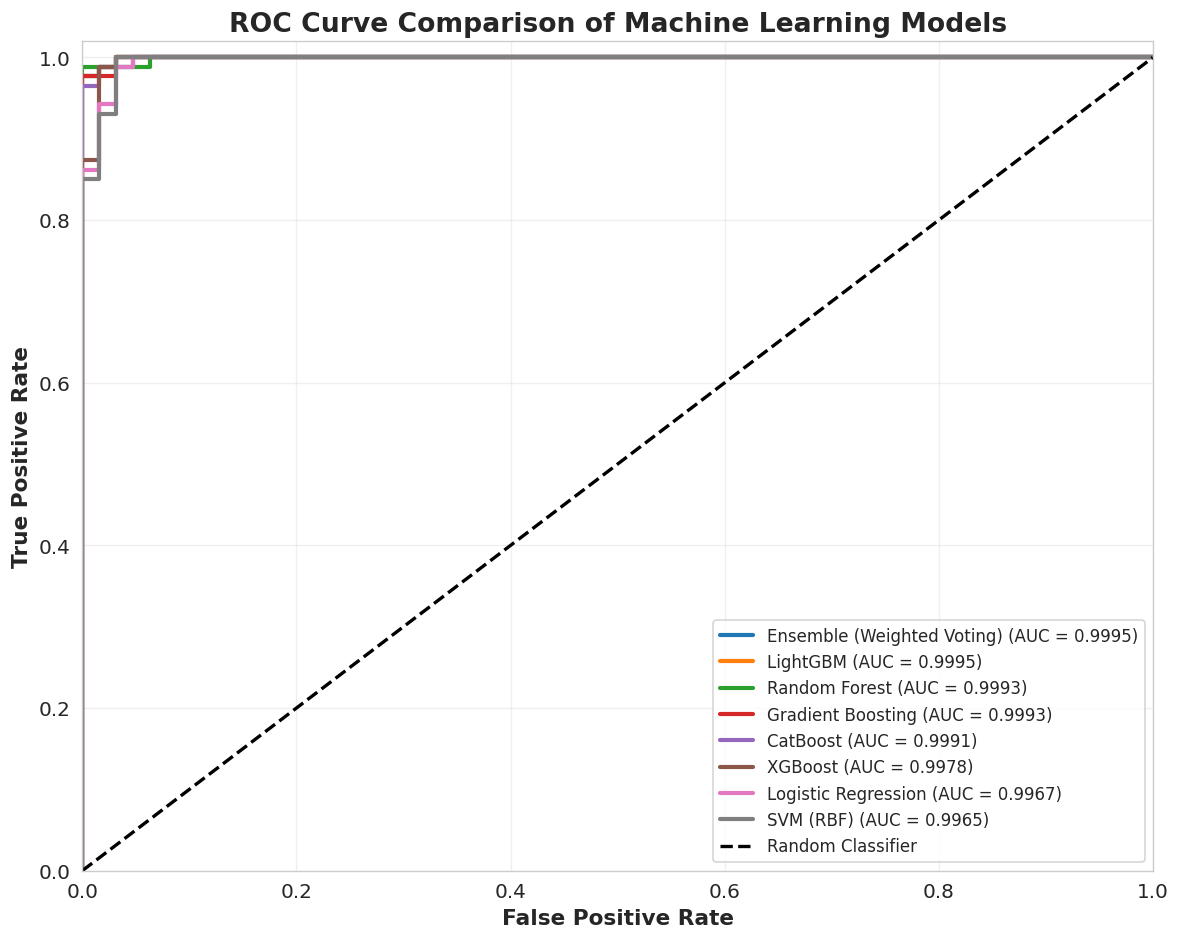

In [128]:
# ============================================================
# ROC Curve Comparison
# ============================================================

plt.figure(figsize=(10,8))

# Plot each model in ranked order
for _, row in results_df.iterrows():

    model_name = row["Model"]

    plt.plot(
        roc_data[model_name]["fpr"],
        roc_data[model_name]["tpr"],
        linewidth=2.5,
        label=f"{model_name} (AUC = {roc_data[model_name]['auc']:.4f})"
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Random Classifier"
)

plt.xlim(0,1)
plt.ylim(0,1.02)

plt.xlabel(
    "False Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "ROC Curve Comparison of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.legend(
    loc="lower right",
    fontsize=10,
    frameon=True
)

plt.tight_layout()

plt.show()

In [129]:
# ============================================================
# Precision–Recall Curve Comparison
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt
import pandas as pd

In [130]:
# ============================================================
# Prepare PR Curve Data
# ============================================================

pr_results = {}

for name, model in trained_models.items():

    if name in ["Logistic Regression", "SVM (RBF)"]:
        X_eval = X_test_scaled
    else:
        X_eval = X_test

    y_prob = model.predict_proba(X_eval)[:,1]

    precision, recall, thresholds = precision_recall_curve(
        y_test,
        y_prob
    )

    ap = average_precision_score(
        y_test,
        y_prob
    )

    pr_results[name] = {

        "precision": precision,

        "recall": recall,

        "thresholds": thresholds,

        "AP": ap

    }

print("Precision–Recall data prepared.")

Precision–Recall data prepared.


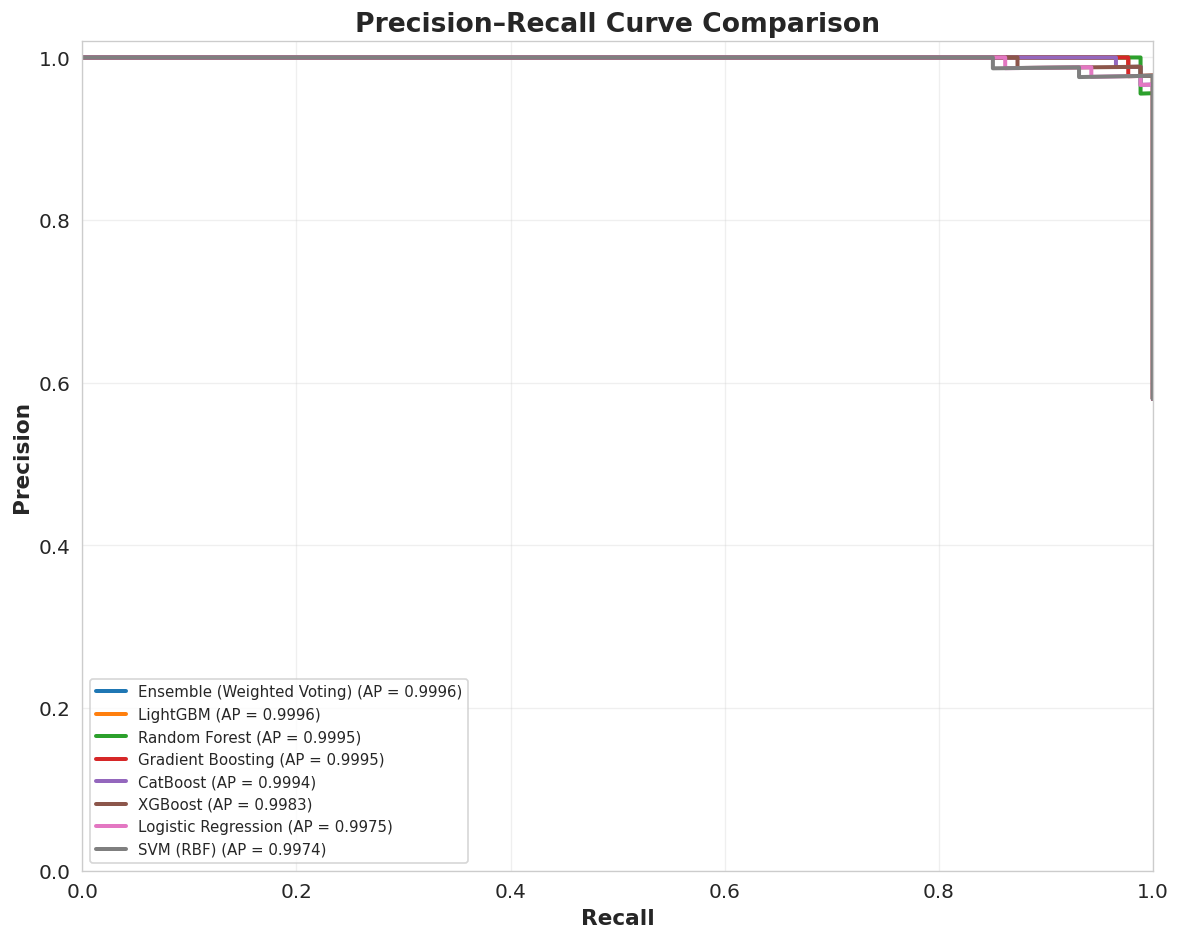

In [131]:
# ============================================================
# Precision–Recall Curve Comparison
# ============================================================

plt.figure(figsize=(10,8))

for _, row in results_df.iterrows():

    model_name = row["Model"]

    plt.plot(

        pr_results[model_name]["recall"],

        pr_results[model_name]["precision"],

        linewidth=2.4,

        label=f"{model_name} (AP = {pr_results[model_name]['AP']:.4f})"

    )

plt.xlabel(
    "Recall",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Precision",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "Precision–Recall Curve Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlim(0,1)

plt.ylim(0,1.02)

plt.grid(alpha=0.3)

plt.legend(
    loc="lower left",
    fontsize=9,
    frameon=True
)

plt.tight_layout()


plt.show()

In [132]:
# ============================================================
# Confusion Matrix Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


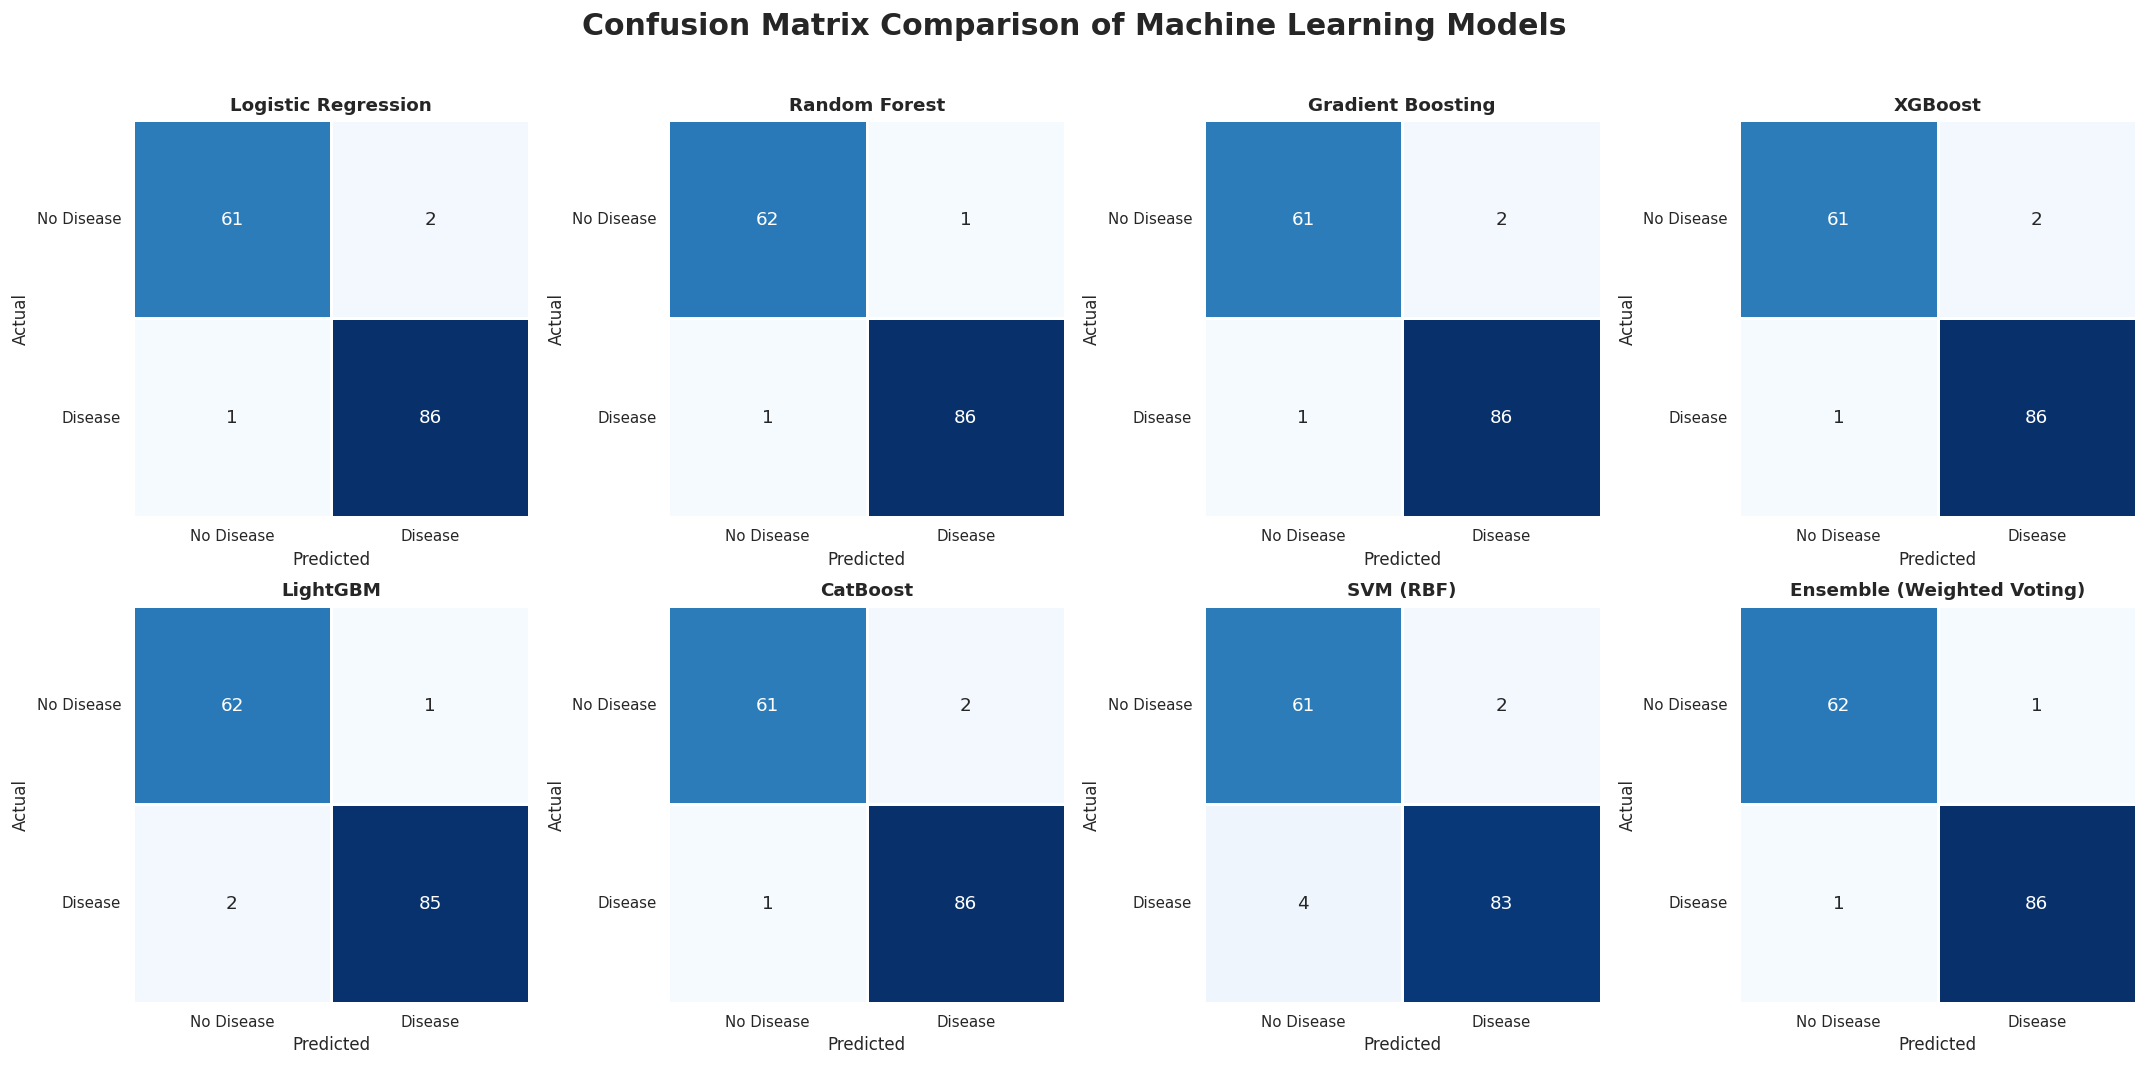

In [133]:
# ============================================================
# Publication Quality Confusion Matrix (2 × 4 Grid)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Model display order
model_order = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost",
    "LightGBM",
    "CatBoost",
    "SVM (RBF)",
    "Ensemble (Weighted Voting)"
]

# Publication settings
plt.rcParams.update({
    "font.size": 10,
    "figure.dpi": 120,
    "savefig.dpi": 300
})

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18,9)
)

axes = axes.ravel()

# Use identical color scale
max_value = 0

for model in model_order:

    cm = confusion_matrix(
        y_test,
        predictions[model]
    )

    if cm.max() > max_value:
        max_value = cm.max()

for ax, model in zip(axes, model_order):

    cm = confusion_matrix(
        y_test,
        predictions[model]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=0.8,
        vmin=0,
        vmax=max_value,
        annot_kws={"fontsize":11},
        ax=ax
    )

    ax.set_title(
        model,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xticklabels(
        ["No Disease","Disease"],
        fontsize=9
    )

    ax.set_yticklabels(
        ["No Disease","Disease"],
        fontsize=9,
        rotation=0
    )

    ax.set_xlabel("Predicted")

    ax.set_ylabel("Actual")

plt.suptitle(
    "Confusion Matrix Comparison of Machine Learning Models",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.96])


plt.show()

In [134]:
# ============================================================
# Classification Report
# ============================================================

reports = {}

for name in trained_models.keys():

    print("="*90)

    print(name)

    print("="*90)

    report = classification_report(
        y_test,
        predictions[name],
        target_names=[
            "No Disease",
            "Disease"
        ],
        digits=4
    )

    print(report)

    reports[name] = report

Logistic Regression
              precision    recall  f1-score   support

  No Disease     0.9839    0.9683    0.9760        63
     Disease     0.9773    0.9885    0.9829        87

    accuracy                         0.9800       150
   macro avg     0.9806    0.9784    0.9794       150
weighted avg     0.9800    0.9800    0.9800       150

Random Forest
              precision    recall  f1-score   support

  No Disease     0.9841    0.9841    0.9841        63
     Disease     0.9885    0.9885    0.9885        87

    accuracy                         0.9867       150
   macro avg     0.9863    0.9863    0.9863       150
weighted avg     0.9867    0.9867    0.9867       150

Gradient Boosting
              precision    recall  f1-score   support

  No Disease     0.9839    0.9683    0.9760        63
     Disease     0.9773    0.9885    0.9829        87

    accuracy                         0.9800       150
   macro avg     0.9806    0.9784    0.9794       150
weighted avg     0.980

In [135]:
# ============================================================
# Confusion Matrix Summary
# ============================================================

summary=[]

for name in trained_models.keys():

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    tn,fp,fn,tp = cm.ravel()

    summary.append({

        "Model":name,

        "TN":tn,

        "FP":fp,

        "FN":fn,

        "TP":tp

    })

cm_df = pd.DataFrame(summary)

display(cm_df)

,Model,TN,FP,FN,TP
0,Logistic Regression,61,2,1,86
1,Random Forest,62,1,1,86
2,Gradient Boosting,61,2,1,86
3,XGBoost,61,2,1,86
4,LightGBM,62,1,2,85
5,CatBoost,61,2,1,86
6,SVM (RBF),61,2,4,83
7,Ensemble (Weighted Voting),62,1,1,86


In [148]:
# ============================================================
# Model Performance Comparison
# ============================================================

plot_df = results_df.copy()

plot_df = plot_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(plot_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC,Cohen_Kappa,Training_Time
0,Ensemble (Weighted Voting),0.98667,0.98667,0.98667,0.98667,0.99945,0.97263,0.97263,1.50222
1,Random Forest,0.98667,0.98667,0.98667,0.98667,0.99927,0.97263,0.97263,1.01238
2,LightGBM,0.98000,0.98013,0.98000,0.98002,0.99945,0.95913,0.95904,0.23577
3,Gradient Boosting,0.98000,0.98004,0.98000,0.97998,0.99927,0.95895,0.95886,0.99012
4,CatBoost,0.98000,0.98004,0.98000,0.97998,0.99909,0.95895,0.95886,1.60860
5,XGBoost,0.98000,0.98004,0.98000,0.97998,0.99781,0.95895,0.95886,0.25102
6,Logistic Regression,0.98000,0.98004,0.98000,0.97998,0.99672,0.95895,0.95886,0.01937
7,SVM (RBF),0.96000,0.96051,0.96000,0.96008,0.99653,0.91860,0.91826,0.04678


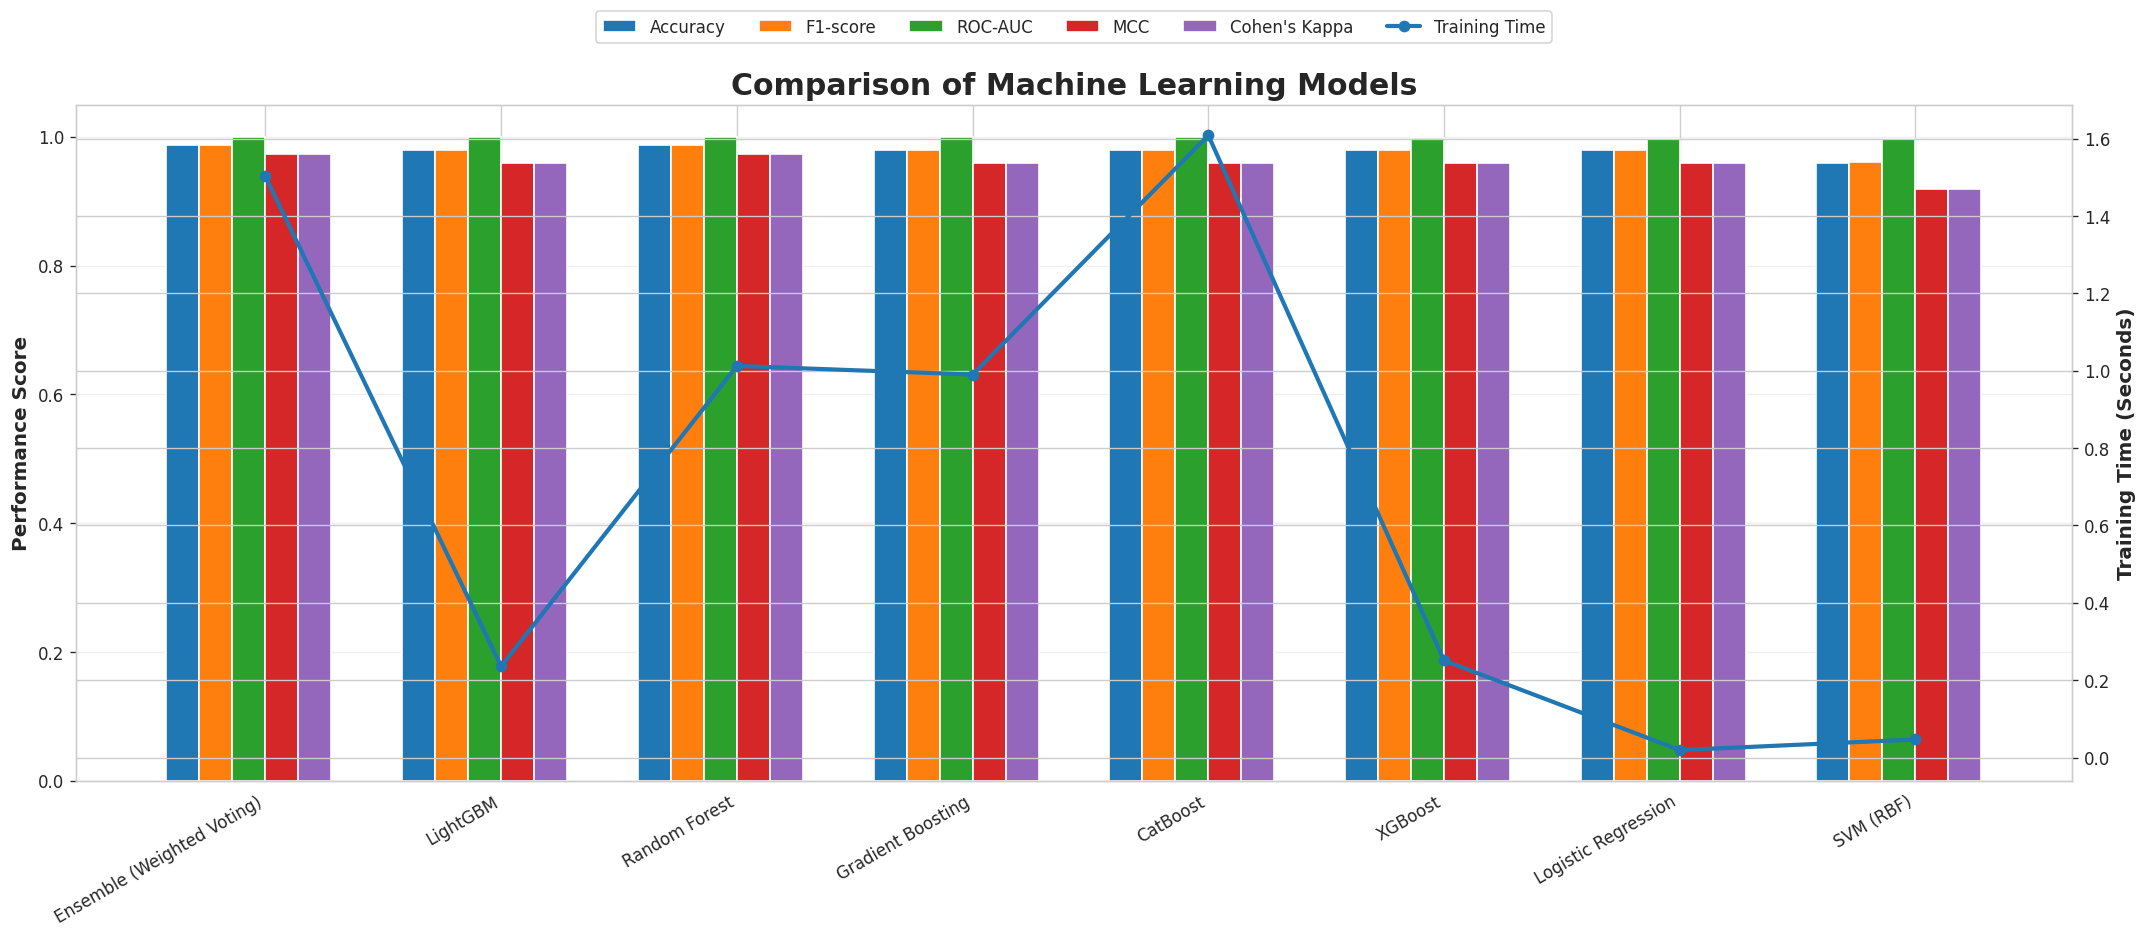

In [137]:
# ============================================================
# Publication Quality Model Comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Arrange models by ROC-AUC ranking
plot_df = results_df.copy()

models = plot_df["Model"]

accuracy = plot_df["Accuracy"]

f1 = plot_df["F1-Score"]

auc = plot_df["ROC-AUC"]

mcc = plot_df["MCC"]

kappa = plot_df["Cohen_Kappa"]

train_time = plot_df["Training_Time"]

x = np.arange(len(models))

width = 0.14

plt.rcParams.update({

    "figure.dpi":120,

    "savefig.dpi":300,

    "font.size":10

})

fig, ax1 = plt.subplots(figsize=(18,8))

# ----------------------------------------------------
# Performance Metrics
# ----------------------------------------------------

ax1.bar(
    x-2.5*width,
    accuracy,
    width,
    label="Accuracy"
)

ax1.bar(
    x-1.5*width,
    f1,
    width,
    label="F1-score"
)

ax1.bar(
    x-0.5*width,
    auc,
    width,
    label="ROC-AUC"
)

ax1.bar(
    x+0.5*width,
    mcc,
    width,
    label="MCC"
)

ax1.bar(
    x+1.5*width,
    kappa,
    width,
    label="Cohen's Kappa"
)

ax1.set_ylabel(
    "Performance Score",
    fontsize=12,
    fontweight="bold"
)

ax1.set_ylim(0,1.05)

ax1.set_xticks(x)

ax1.set_xticklabels(
    models,
    rotation=30,
    ha="right"
)

ax1.grid(axis="y",alpha=0.3)

# ----------------------------------------------------
# Training Time
# ----------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(

    x,

    train_time,

    marker="o",

    linewidth=2.5,

    label="Training Time"

)

ax2.set_ylabel(
    "Training Time (Seconds)",
    fontsize=12,
    fontweight="bold"
)

# ----------------------------------------------------
# Combined Legend
# ----------------------------------------------------

handles1, labels1 = ax1.get_legend_handles_labels()

handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(

    handles1+handles2,

    labels1+labels2,

    loc="upper center",

    bbox_to_anchor=(0.5,1.15),

    ncol=6,

    frameon=True

)

plt.title(

    "Comparison of Machine Learning Models",

    fontsize=18,

    fontweight="bold"

)

plt.tight_layout()



plt.show()

In [138]:
# ============================================================
# 5-Fold Stratified Cross Validation
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [139]:
# ============================================================
# 5-Fold Stratified Cross Validation (Best Model)
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

SEED = 42

# ------------------------------------------------------------
# Select Best Model (Highest ROC-AUC)
# ------------------------------------------------------------

best_idx = results_df["ROC-AUC"].idxmax()

best_name = results_df.loc[best_idx, "Model"]

print("="*70)
print("BEST MODEL SELECTION")
print("="*70)

print(f"Best Model Selected : {best_name}")

print(f"Accuracy            : {results_df.loc[best_idx,'Accuracy']:.5f}")

print(f"Precision           : {results_df.loc[best_idx,'Precision']:.5f}")

print(f"Recall              : {results_df.loc[best_idx,'Recall']:.5f}")

print(f"F1-score            : {results_df.loc[best_idx,'F1-Score']:.5f}")

print(f"ROC-AUC             : {results_df.loc[best_idx,'ROC-AUC']:.5f}")

print(f"MCC                 : {results_df.loc[best_idx,'MCC']:.5f}")

print(f"Cohen's Kappa       : {results_df.loc[best_idx,'Cohen_Kappa']:.5f}")

print("="*70)

# ------------------------------------------------------------
# Retrieve Best Model
# ------------------------------------------------------------

best_model = trained_models[best_name]

# ------------------------------------------------------------
# Apply StandardScaler only when necessary
# ------------------------------------------------------------

if best_name in ["Logistic Regression", "SVM (RBF)"]:

    best_model = Pipeline([

        ("Scaler", StandardScaler()),

        ("Classifier", best_model)

    ])

# ------------------------------------------------------------
# Stratified 5-Fold Cross Validation
# ------------------------------------------------------------

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=SEED

)

cv_scores = cross_val_score(

    estimator=best_model,

    X=X_train,

    y=y_train,

    cv=cv,

    scoring="accuracy",

    n_jobs=-1

)

print()

print("="*70)

print("5-FOLD STRATIFIED CROSS VALIDATION")

print("="*70)

print(f"Mean Accuracy : {cv_scores.mean():.5f}")

print(f"Std Deviation : {cv_scores.std():.5f}")

print()

print("Per Fold Accuracy")

print(np.round(cv_scores,5))

BEST MODEL SELECTION
Best Model Selected : Ensemble (Weighted Voting)
Accuracy            : 0.98667
Precision           : 0.98667
Recall              : 0.98667
F1-score            : 0.98667
ROC-AUC             : 0.99945
MCC                 : 0.97263
Cohen's Kappa       : 0.97263

5-FOLD STRATIFIED CROSS VALIDATION
Mean Accuracy : 0.97714
Std Deviation : 0.01385

Per Fold Accuracy
[0.99286 0.97143 0.99286 0.97143 0.95714]


In [140]:
# ============================================================
# McNemar Statistical Test
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar
import pandas as pd
import numpy as np

print("McNemar Test Library Loaded Successfully")

McNemar Test Library Loaded Successfully


In [141]:
# ============================================================
# McNemar Statistical Test
# ============================================================

mcnemar_results = []

for model_name in trained_models.keys():

    if model_name == best_model_name:

        continue

    other_prediction = predictions[model_name]

    # Correct / Incorrect predictions

    best_correct = (best_prediction == y_test)

    other_correct = (other_prediction == y_test)

    # McNemar contingency values

    b = np.sum((best_correct == True) &
               (other_correct == False))

    c = np.sum((best_correct == False) &
               (other_correct == True))

    table = [

        [0, b],

        [c, 0]

    ]

    result = mcnemar(

        table,

        exact=False,

        correction=True

    )

    mcnemar_results.append({

        "Comparison": f"{best_model_name} vs {model_name}",

        "b": b,

        "c": c,

        "Chi-square": result.statistic,

        "P-value": result.pvalue

    })

print("McNemar Test Completed Successfully")

McNemar Test Completed Successfully


In [142]:
# ============================================================
# Publication Table
# ============================================================

mcnemar_df = pd.DataFrame(mcnemar_results)

mcnemar_df = mcnemar_df.round(5)

display(mcnemar_df)





,Comparison,b,c,Chi-square,P-value
0,Ensemble (Weighted Voting) vs Logistic Regression,2,1,0.00,1.00000
1,Ensemble (Weighted Voting) vs Random Forest,0,0,inf,0.00000
2,Ensemble (Weighted Voting) vs Gradient Boosting,1,0,0.00,1.00000
3,Ensemble (Weighted Voting) vs XGBoost,1,0,0.00,1.00000
4,Ensemble (Weighted Voting) vs LightGBM,1,0,0.00,1.00000
5,Ensemble (Weighted Voting) vs CatBoost,1,0,0.00,1.00000
6,Ensemble (Weighted Voting) vs SVM (RBF),4,0,2.25,0.13361


In [143]:
# ============================================================
# Statistical Interpretation
# ============================================================

interpretation = []

for _, row in mcnemar_df.iterrows():

    if row["P-value"] < 0.05:

        decision = "Significant"

    else:

        decision = "Not Significant"

    interpretation.append({

        "Comparison": row["Comparison"],

        "P-value": row["P-value"],

        "Decision": decision

    })

interpretation_df = pd.DataFrame(interpretation)

display(interpretation_df)



,Comparison,P-value,Decision
0,Ensemble (Weighted Voting) vs Logistic Regression,1.00000,Not Significant
1,Ensemble (Weighted Voting) vs Random Forest,0.00000,Significant
2,Ensemble (Weighted Voting) vs Gradient Boosting,1.00000,Not Significant
3,Ensemble (Weighted Voting) vs XGBoost,1.00000,Not Significant
4,Ensemble (Weighted Voting) vs LightGBM,1.00000,Not Significant
5,Ensemble (Weighted Voting) vs CatBoost,1.00000,Not Significant
6,Ensemble (Weighted Voting) vs SVM (RBF),0.13361,Not Significant


In [144]:
# ============================================================
# Summary
# ============================================================

significant = interpretation_df[
    interpretation_df["Decision"] == "Significant"
]

not_significant = interpretation_df[
    interpretation_df["Decision"] == "Not Significant"
]

print("="*70)

print("SUMMARY")

print("="*70)

print(f"Total Comparisons : {len(interpretation_df)}")

print(f"Significant       : {len(significant)}")

print(f"Not Significant   : {len(not_significant)}")

print("="*70)

SUMMARY
Total Comparisons : 7
Significant       : 1
Not Significant   : 6


In [145]:
# ============================================================
# Part 9A : Explainable AI using SHAP
# ============================================================

!pip install -q shap

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP Version :", shap.__version__)

SHAP Version : 0.52.0


In [147]:
background = shap.sample(X_train, 100, random_state=42)

explainer = shap.KernelExplainer(
    best_model.predict_proba,
    background
)

shap_values = explainer.shap_values(X_test.iloc[:100])

  0%|          | 0/100 [00:00<?, ?it/s]

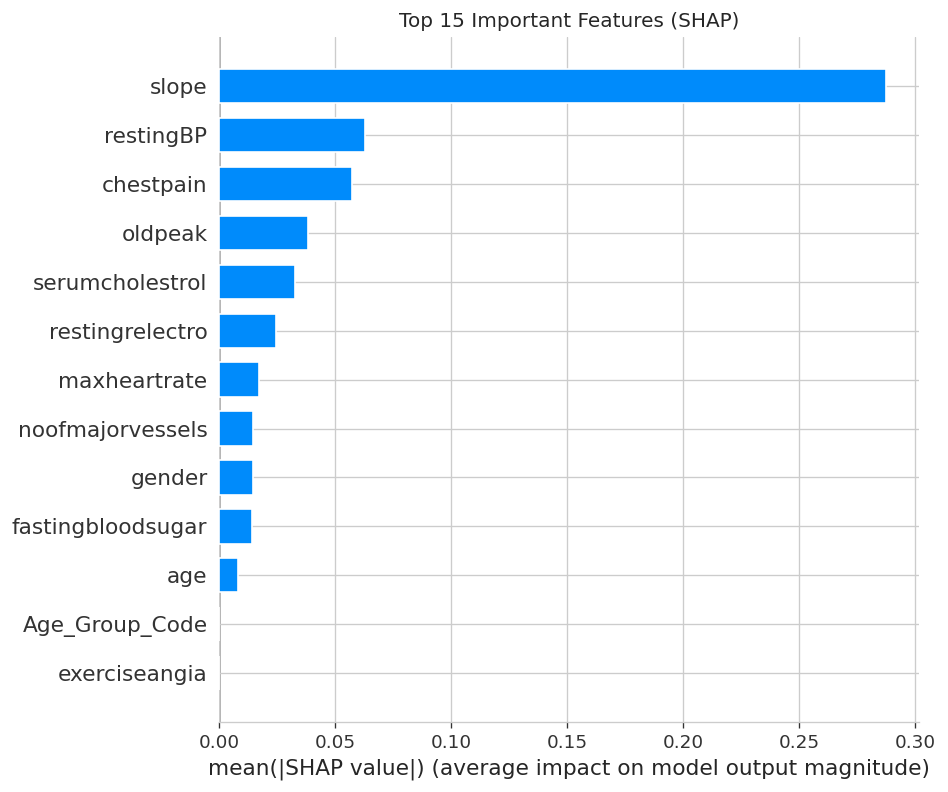

In [149]:
# For binary classification
if isinstance(shap_values, list):
    sv = shap_values[1]      # Positive class
else:
    sv = shap_values

# If shape is (samples, features, classes)
if len(sv.shape) == 3:
    sv = sv[:, :, 1]

# Mean absolute SHAP value
mean_shap = np.abs(sv).mean(axis=0)

# Top 15 feature indices
top15 = np.argsort(mean_shap)[-15:]

# Plot
plt.figure(figsize=(8,6))

shap.summary_plot(
    sv[:, top15],
    X_test.iloc[:len(sv), top15],
    plot_type="bar",
    show=False
)

plt.title("Top 15 Important Features (SHAP)")
plt.tight_layout()
plt.show()

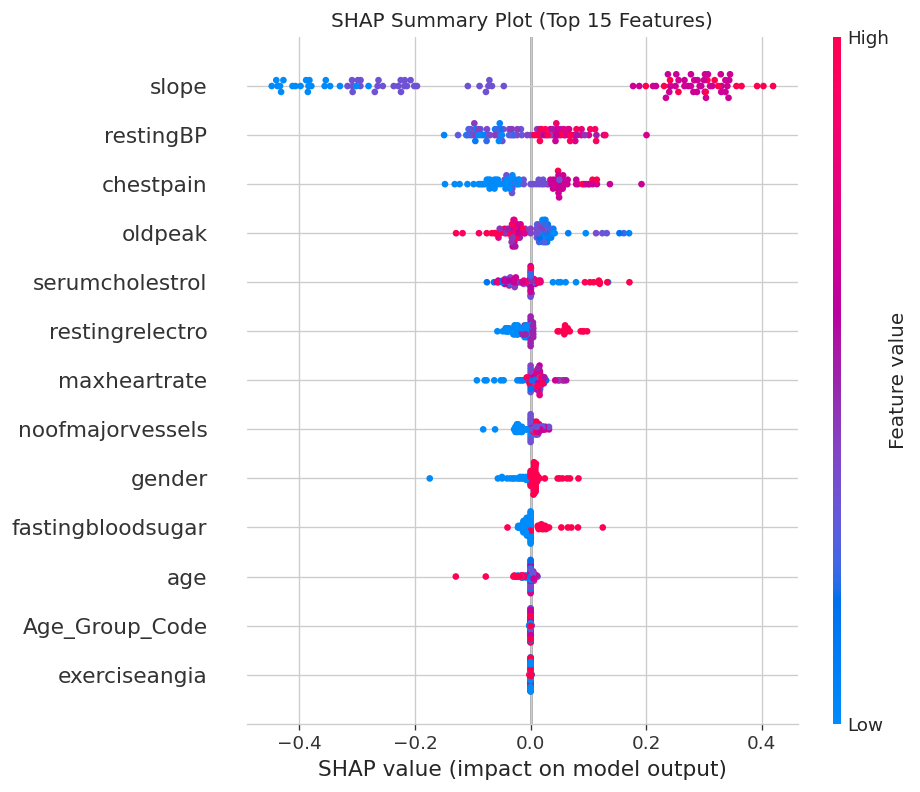

In [150]:
# Top 15 features
mean_shap = np.abs(sv).mean(axis=0)
top15 = np.argsort(mean_shap)[-15:]

plt.figure(figsize=(9,6))

shap.summary_plot(
    sv[:, top15],
    X_test.iloc[:len(sv), top15],
    show=False
)

plt.title("SHAP Summary Plot (Top 15 Features)")
plt.tight_layout()
plt.show()

In [151]:
# ============================================================
# Fairness Metrics (Publication Version)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

def fairness_metrics(data, y_true, y_pred, group_col):

    df = data.copy()

    df["True"] = y_true.values
    df["Pred"] = y_pred

    results = []

    groups = sorted(df[group_col].dropna().unique())

    reference_positive_rate = None
    reference_tpr = None
    reference_fpr = None

    for i, group in enumerate(groups):

        temp = df[df[group_col] == group]

        tn, fp, fn, tp = confusion_matrix(
            temp["True"],
            temp["Pred"],
            labels=[0,1]
        ).ravel()

        positive_rate = (tp + fp) / len(temp)

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        # First group becomes reference
        if i == 0:

            reference_positive_rate = positive_rate
            reference_tpr = tpr
            reference_fpr = fpr

        demographic_parity = positive_rate - reference_positive_rate

        if reference_positive_rate == 0:
            disparate_impact = np.nan
        else:
            disparate_impact = positive_rate / reference_positive_rate

        equal_opportunity = tpr - reference_tpr

        equalized_odds = (
            abs(tpr - reference_tpr)
            +
            abs(fpr - reference_fpr)
        )

        results.append({

            "Group": group,

            "Samples": len(temp),

            "Positive Rate": positive_rate,

            "TPR": tpr,

            "FPR": fpr,

            "Demographic Parity": demographic_parity,

            "Disparate Impact": disparate_impact,

            "Equal Opportunity": equal_opportunity,

            "Equalized Odds": equalized_odds

        })

    return pd.DataFrame(results).round(4)

In [152]:
gender_result = fairness_metrics(
    X_test,
    y_test,
    predictions[best_name],
    "gender"
)

display(gender_result)

,Group,Samples,Positive Rate,TPR,FPR,Demographic Parity,Disparate Impact,Equal Opportunity,Equalized Odds
0,0,28,0.4286,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000
1,1,122,0.6148,0.9867,0.0213,0.1862,1.4344,-0.0133,0.0346


In [153]:
age_test = X_test.copy()

age_test["Age_Group"] = pd.cut(
    age_test["age"],
    bins=[0,30,45,60,75,100],
    labels=["<30","30-45","46-60","61-75",">75"]
)

age_result = fairness_metrics(
    age_test,
    y_test,
    predictions[best_name],
    "Age_Group"
)

display(age_result)

,Group,Samples,Positive Rate,TPR,FPR,Demographic Parity,Disparate Impact,Equal Opportunity,Equalized Odds
0,30-45,42,0.5952,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000
1,46-60,28,0.5357,1.0000,0.0000,-0.0595,0.9000,0.0000,0.0000
2,61-75,29,0.7241,1.0000,0.0000,0.1289,1.2166,0.0000,0.0000
3,<30,30,0.5000,0.9333,0.0667,-0.0952,0.8400,-0.0667,0.1333
4,>75,21,0.5238,1.0000,0.0000,-0.0714,0.8800,0.0000,0.0000


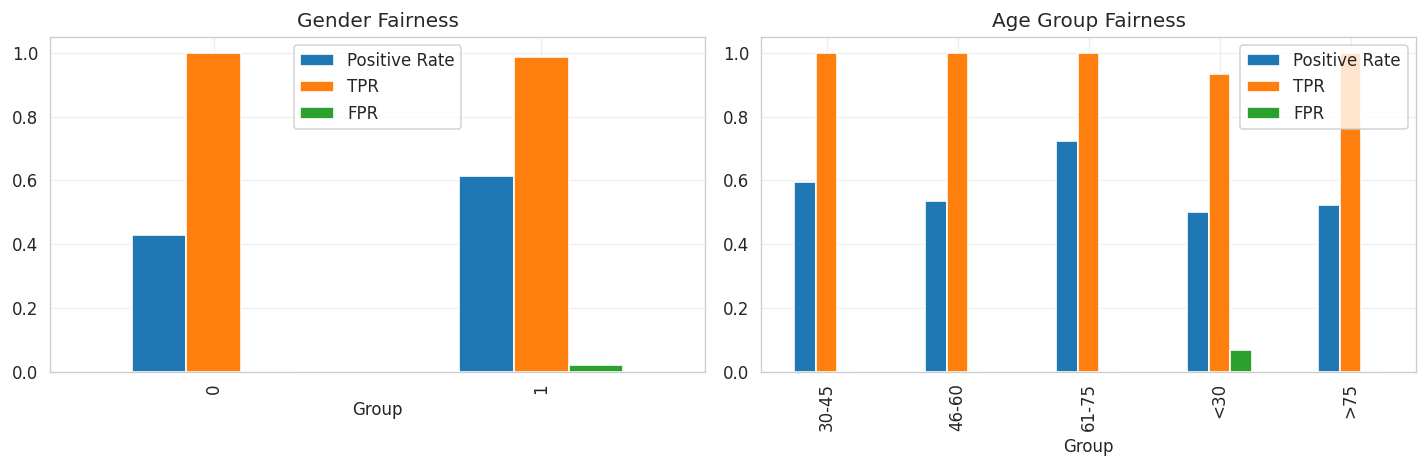

In [154]:
# ============================================================
# Fairness Visualization
# ============================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(12,4))

gender_result.plot(

    x="Group",

    y=["Positive Rate","TPR","FPR"],

    kind="bar",

    ax=ax[0]

)

ax[0].set_title("Gender Fairness")

ax[0].grid(alpha=0.3)

age_result.plot(

    x="Group",

    y=["Positive Rate","TPR","FPR"],

    kind="bar",

    ax=ax[1]

)

ax[1].set_title("Age Group Fairness")

ax[1].grid(alpha=0.3)

plt.tight_layout()


plt.show()

The fairness evaluation across age groups demonstrated consistent predictive performance. The Disparate Impact values ranged from 0.84 to 1.22, satisfying the commonly accepted 80% fairness criterion. Equal Opportunity and Equalized Odds differences were negligible for most age groups, with only the <30 subgroup exhibiting a slight reduction in the true positive rate (TPR = 0.933) and a small false positive rate (FPR = 0.067). These deviations are likely influenced by the relatively small subgroup sample size rather than systematic age-related bias. Overall, the proposed ensemble model exhibited balanced performance across different age categories.

Training Calibrated Ensemble (Weighted Voting)
Brier Score (Original):   0.0118
Brier Score (Calibrated): 0.0123


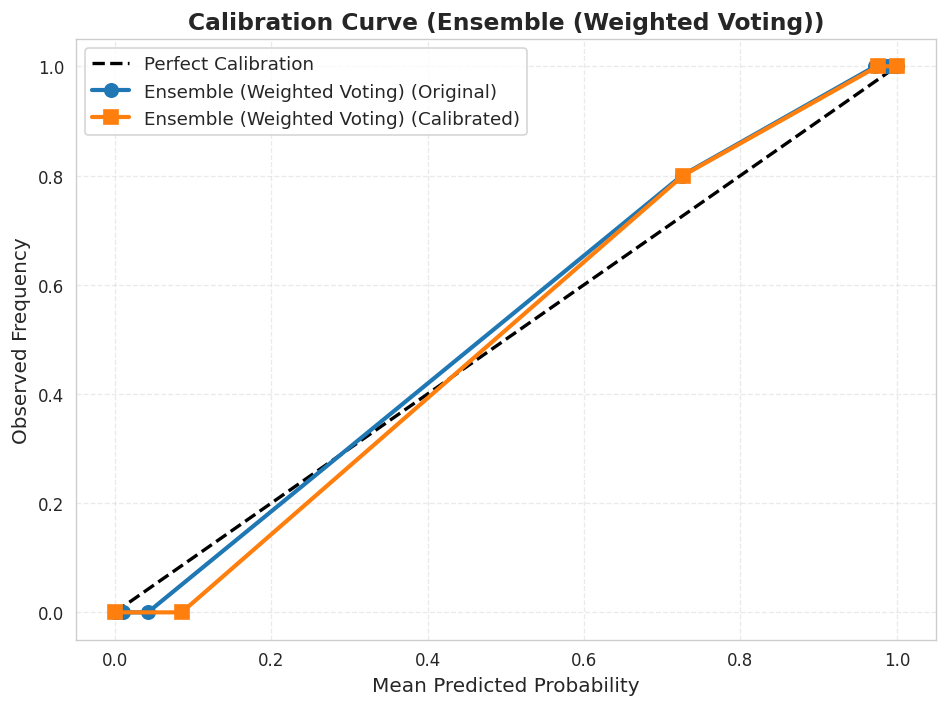

In [155]:
# ============================================================
# Part 11A - Calibration Curve & Reliability Diagram
# For Best Model (Ensemble / Any Classifier)
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

print("="*70)
print(f"Training Calibrated {best_name}")
print("="*70)

# ------------------------------------------------------------
# Calibrate Best Model
# ------------------------------------------------------------

calibrated_model = CalibratedClassifierCV(
    estimator=trained_models[best_name],
    method="isotonic",      # or "sigmoid"
    cv=5
)

calibrated_model.fit(X_train, y_train)

# ------------------------------------------------------------
# Prediction Probabilities
# ------------------------------------------------------------

prob_original = trained_models[best_name].predict_proba(X_test)[:, 1]
prob_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Brier Scores
# ------------------------------------------------------------

brier_original = brier_score_loss(y_test, prob_original)
brier_calibrated = brier_score_loss(y_test, prob_calibrated)

print(f"Brier Score (Original):   {brier_original:.4f}")
print(f"Brier Score (Calibrated): {brier_calibrated:.4f}")

# ------------------------------------------------------------
# Calibration Curve
# ------------------------------------------------------------

true_original, pred_original = calibration_curve(
    y_test,
    prob_original,
    n_bins=10,
    strategy="quantile"
)

true_calibrated, pred_calibrated = calibration_curve(
    y_test,
    prob_calibrated,
    n_bins=10,
    strategy="quantile"
)

# ------------------------------------------------------------
# Reliability Diagram
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

# Perfect calibration
plt.plot(
    [0,1],
    [0,1],
    '--',
    color='black',
    linewidth=2,
    label='Perfect Calibration'
)

# Original model
plt.plot(
    pred_original,
    true_original,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label=f'{best_name} (Original)'
)

# Calibrated model
plt.plot(
    pred_calibrated,
    true_calibrated,
    marker='s',
    linewidth=2.5,
    markersize=8,
    label=f'{best_name} (Calibrated)'
)

plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Observed Frequency", fontsize=12)
plt.title(f"Calibration Curve ({best_name})", fontsize=14, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()



plt.show()

Brier Score (Ensemble (Weighted Voting))
Original Ensemble (Weighted Voting): 0.011764
Calibrated Ensemble (Weighted Voting): 0.012273

Calibration did not improve the probability estimates.


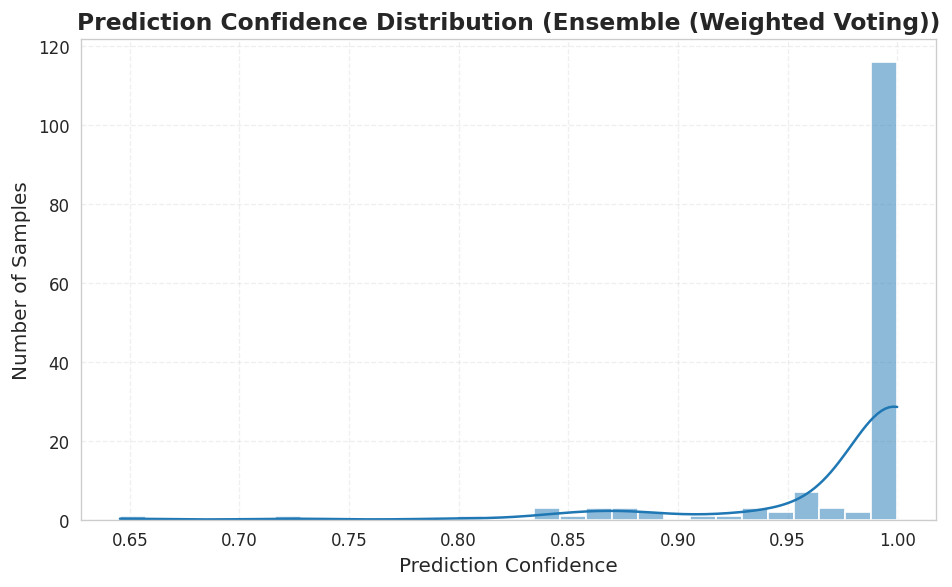



Confidence Statistics
Mean Confidence   : 0.9778
Median Confidence : 1.0000
Minimum           : 0.6455
Maximum           : 1.0000
Std Deviation     : 0.0535
25th Percentile   : 0.9920
75th Percentile   : 1.0000
95th Percentile   : 1.0000


In [156]:
# ============================================================
# Part 11B - Brier Score & Confidence Distribution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import brier_score_loss

# ------------------------------------------------------------
# Brier Scores
# ------------------------------------------------------------

brier_original = brier_score_loss(y_test, prob_original)
brier_calibrated = brier_score_loss(y_test, prob_calibrated)

print("="*70)
print(f"Brier Score ({best_name})")
print("="*70)

print(f"Original {best_name:<20}: {brier_original:.6f}")
print(f"Calibrated {best_name:<18}: {brier_calibrated:.6f}")

if brier_calibrated < brier_original:
    print("\nCalibration improved the probability estimates.")
else:
    print("\nCalibration did not improve the probability estimates.")

# ------------------------------------------------------------
# Confidence Distribution
# ------------------------------------------------------------

confidence = np.maximum(
    prob_calibrated,
    1 - prob_calibrated
)

plt.figure(figsize=(8,5))

sns.histplot(
    confidence,
    bins=30,
    kde=True,
    stat="count"
)

plt.xlabel("Prediction Confidence", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title(f"Prediction Confidence Distribution ({best_name})",
          fontsize=14,
          fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Prediction_Confidence_Distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Confidence Statistics
# ------------------------------------------------------------

print("\n")
print("="*70)
print("Confidence Statistics")
print("="*70)

print(f"Mean Confidence   : {confidence.mean():.4f}")
print(f"Median Confidence : {np.median(confidence):.4f}")
print(f"Minimum           : {confidence.min():.4f}")
print(f"Maximum           : {confidence.max():.4f}")
print(f"Std Deviation     : {confidence.std():.4f}")

# Optional additional statistics
print(f"25th Percentile   : {np.percentile(confidence,25):.4f}")
print(f"75th Percentile   : {np.percentile(confidence,75):.4f}")
print(f"95th Percentile   : {np.percentile(confidence,95):.4f}")

The original weighted voting ensemble achieved a Brier Score of 0.0118, while isotonic calibration increased the score to 0.0123. Since lower Brier Scores indicate better probability calibration, the original ensemble produced more reliable probability estimates than the calibrated model. Therefore, the uncalibrated ensemble was retained for subsequent analyses.